# MGS-1 Reduced-Mass Geotechnical Index Testing

This is the streamlined GitHub notebook for the final thesis figure set. It reproduces the figures retained in the thesis and omits exploratory or superseded alternatives.


## How to Run

Run this notebook from the repository root after installing the packages in `requirements.txt`.

Inputs are read from `data/`. Final outputs are written to `tables/`, `figures/`, and `figures_word/`.

This notebook keeps the final selected versions only: Figure 3.13 uses the median ± 1 SD version, Figure 4.4 uses the point/line median ± 1 SD version, and Figure 4.5 keeps the replicate/median D$_{50}$ plot only.

---

## 0. Setup


In [1]:
import re
import statistics as stats
from pathlib import Path

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
TABLE_DIR = Path("tables")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from openpyxl import load_workbook


### 0.1 Figure Style
Shared Matplotlib defaults for non-PSD figures. PSD figures use the dedicated `PLOT_CFG` settings below.


In [2]:
# -- Global figure style -------------------------------------------------------
# Figures are drawn at final Word text width instead of being exported as very
# large raster images and then downscaled by Word. This keeps text/line weights
# predictable and reduces quality loss during Word-to-PDF export.
WORD_TEXT_WIDTH_IN = 6.5
STYLE_CFG = {
    "figsize"     : (WORD_TEXT_WIDTH_IN, 4.2),
    "dpi_screen"  : 120,
    "dpi_save"    : 300,
    "font_size"   : 9.5,
    "title_size"  : 10.0,
    "label_size"  : 9.5,
    "legend_size" : 8.5,
    "linewidth"   : 1.25,
    "markersize"  : 3.5,
    "grid_alpha"  : 0.30,
}

# Word/Office often softens raster images when exporting a .docx to PDF.
# Therefore each figure is saved as:
#   1) PDF: archival/vector thesis figure
#   2) SVG: recommended Word input when possible (vector; stays crisp in PDF export)
#   3) 450 dpi PNG: raster fallback at final thesis width
WORD_DPI = 450
PAD_INCHES = 0.04

def apply_style(cfg=None):
    c = STYLE_CFG if cfg is None else cfg
    plt.rcParams.update({
        "figure.figsize"  : c["figsize"],
        "figure.dpi"      : c["dpi_screen"],
        "savefig.dpi"     : c["dpi_save"],
        "font.size"       : c["font_size"],
        "axes.titlesize"  : c["title_size"],
        "axes.labelsize"  : c["label_size"],
        "legend.fontsize" : c["legend_size"],
        "xtick.labelsize" : 8.0,
        "ytick.labelsize" : 8.0,
        "lines.linewidth" : c["linewidth"],
        "lines.markersize": c["markersize"],
        "axes.grid"       : True,
        "grid.linewidth"  : 0.30,
        "axes.spines.top"   : True,
        "axes.spines.right" : True,
        "axes.spines.left"  : True,
        "axes.spines.bottom": True,
        "pdf.fonttype"    : 42,
        "ps.fonttype"     : 42,
        "svg.fonttype"    : "none",
    })

apply_style()

OUT = Path("figures")
WORD_PNG_OUT = Path(f"figures_word/png_{WORD_DPI}dpi")
WORD_SVG_OUT = Path("figures_word/svg")
for _out in (OUT, WORD_PNG_OUT, WORD_SVG_OUT):
    _out.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, fmt="pdf", tight=True):
    """Save archival PDF, Word-ready SVG, and final-size high-DPI PNG fallback."""
    pdf_path = OUT / f"{name}.pdf"
    svg_path = WORD_SVG_OUT / f"{name}.svg"
    word_png_path = WORD_PNG_OUT / f"{name}.png"
    save_kwargs = dict(facecolor="white")
    if tight:
        save_kwargs.update(bbox_inches="tight", pad_inches=PAD_INCHES)
    fig.savefig(pdf_path, format="pdf", dpi=STYLE_CFG["dpi_save"], **save_kwargs)
    fig.savefig(svg_path, format="svg", **save_kwargs)
    fig.savefig(word_png_path, format="png", dpi=WORD_DPI, metadata={"Software": "Matplotlib"}, **save_kwargs)
    print(f"Saved: {pdf_path}; Word SVG: {svg_path}; Word PNG: {word_png_path}")

G = 9.81  # m/s²

# Keep notebook execution quiet when run as a script.
try:
    display
except NameError:
    def display(*args, **kwargs):
        pass

### 0.2 Mass-Centric Visual Style
A single colour/marker convention is used for each nominal specimen mass across the notebook.


In [3]:
# ── Consistent mass-centric style (B/W-readable) ──────────────────────────────
# Design principle (separates four dimensions while remaining B/W readable):
#   • Mass    -> unique marker shape + colour, kept consistent across all figures
#   • Method -> fill style (dry=filled, wet/hydro=open) + a subtle tint for wet
#   • Replicate -> line style (1=solid, 2=dashed, 3=dotted)
#   • General -> colour for print, still readable in B/W through marker shape and fill
BW_MODE = False   # True for black-and-white version (colours converted to greyscale)

# Marker per specimen mass (distinct shapes for B/W readability)
MASS_MARKER = {
    100: "o",   # circle
    50 : "s",   # square
    10 : "^",   # upward triangle
    2  : "D",   # diamond
    0.5: "X",   # X marker
}

# Colours per specimen mass
MASS_COLOR_RGB = {
    100:  "#CC79A7",  # reddish purple
    50:   "#0072B2",  # blue
    10:   "#E69F00",  # orange
    2:    "#009E73",  # bluish green
    0.5:  "#D55E00",  # vermillion
}
# Greyscale palette for B/W mode (dark to light from large to small mass)
MASS_COLOR_BW = {
    100:  "#000000",
    50:   "#2b2b2b",
    10:   "#5a5a5a",
    2:    "#8a8a8a",
    0.5:  "#b5b5b5",
}

# Method coding
# Fill style: dry = filled, wet + hydro = open
METHOD_FILL = {
    "dry"         : "hollow",
    "wet"         : "filled",
    "hydro_bulk"  : "filled",   # bulk hydrometer is primary: filled, with its own line style
    "hydro_fines" : "hollow",
    "stitched"    : "filled",
}

# Line width per method (dashed/dotted lines look visually thicker at the same lw).
# Reduced after review: sieve/hydrometer signal and stitched median
# were too thick; now more proportional for detailed PSD figures.
METHOD_LW = {
    "dry"         : 1.05,
    "wet"         : 1.05,
    "hydro_bulk"  : 1.05,
    "hydro_fines" : 0.55,
    "stitched"    : 1.15,
}

# Color tint per method (0 = unchanged, 1 = white). Keep a subtle tint for wet.
METHOD_TINT = {
    "dry"         : 0.00,
    "wet"         : 0.08,    # subtle lighter tone so wet is not identical to dry
    "hydro_bulk"  : 0.00,
    "hydro_fines" : 0.05,
    "stitched"    : 0.00,
}

# Line style per replicate (applies to all methods). Used when REPLICATE_LS_ENABLED=True;
# otherwise the method controls the line style (useful when the same linestyle is desired for all
# replicates of the same method).
REPLICATE_LS_ENABLED = True
REPLICATE_LS = {
    0: "-",                   # solid
    1: (0, (7, 2.2)),         # long dashed
    2: (0, (4, 1.2, 1, 1.2)), # dash-dot
    3: (0, (1, 1.4)),         # tight dotted
    4: (0, (8, 1.5, 1, 1.5, 1, 1.5)),
}

# Fallback line style per method (only used when REPLICATE_LS_ENABLED=False).
METHOD_LS_FALLBACK = {
    "dry"         : "-",
    "wet"         : (0, (6, 2)),
    "hydro_bulk"  : (0, (1, 1.2)),
    "hydro_fines" : (0, (4, 1, 1, 1)),
    "stitched"    : "-",
}

def _nearest_mass(mass):
    """Snap an arbitrary mass to the closest nominal group (log-distance).
    Used so 55 g (loose/tapped data) maps to the 50 g style, etc.
    """
    if mass in MASS_MARKER:
        return mass
    keys = list(MASS_MARKER.keys())
    return min(keys, key=lambda k: abs(np.log10(k) - np.log10(mass)))

def mass_color(mass):
    """Return color for a given specimen mass (respects BW_MODE)."""
    m = _nearest_mass(mass)
    return (MASS_COLOR_BW if BW_MODE else MASS_COLOR_RGB)[m]

def mass_marker(mass):
    """Return marker for a given specimen mass."""
    return MASS_MARKER[_nearest_mass(mass)]

def _tint(col, factor):
    """Blend RGB color toward white. factor=0 → unchanged, factor=1 → white."""
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(col)
    return (r + (1-r)*factor, g + (1-g)*factor, b + (1-b)*factor)

# Replicate-specific marker variants for PSD plots. Mass remains encoded by
# colour; replicate identity remains readable in black-and-white by marker + line.
PSD_MARKER_BY_MASS_REP = {
    100: ["o", "v", "p"],
    50:  ["s", "P", "X"],
    10:  ["^", "<", ">"],
    2:   ["D", "d", "h"],
    0.5: ["X", "*", "+"],
}

def psd_marker(mass, replicate_idx=0):
    m = _nearest_mass(mass)
    opts = PSD_MARKER_BY_MASS_REP.get(m, [mass_marker(m)])
    return opts[int(replicate_idx) % len(opts)]

def style_for(mass, method="dry", replicate_idx=0, **overrides):
    """Return a style dict suitable for ax.plot / ax.errorbar.
    Style dimensions:
      • color/marker - per mass
      • line style   - per replicate when REPLICATE_LS_ENABLED, otherwise per method
      • fill style   - per method (dry=filled, wet/hydro_fines=open, hydro_bulk=filled)
      • line width   - per method
      • color tint   - per method (subtle for wet/hydro_fines)
    Mass can be any value; it is snapped to the nearest nominal group.
    """
    base_col = mass_color(mass)
    col = _tint(base_col, METHOD_TINT.get(method, 0.0))
    mk  = psd_marker(mass, replicate_idx)

    # Fyllstil
    fill_kind = METHOD_FILL.get(method, "filled")
    mfc = col if fill_kind == "filled" else "white"

    # Linjestil
    if REPLICATE_LS_ENABLED:
        ls = REPLICATE_LS.get(replicate_idx, "-")
    else:
        ls = METHOD_LS_FALLBACK.get(method, "-")

    lw = METHOD_LW.get(method, 2.0)

    st = dict(color=col, marker=mk, linestyle=ls,
              markerfacecolor=mfc, markeredgecolor=col,
              markeredgewidth=0.9, linewidth=lw, markersize=3.4)
    st.update(overrides)
    return st

def parse_mass(tid):
    """Extract nominal specimen mass from test ID (e.g. '50A', 'F10', '2W1' → 50/10/2)."""
    s = str(tid).replace(",", ".")
    m = re.match(r"^F?(\d+(?:\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan

def parse_rep_idx(tid):
    """Replicate index from suffix (A/W1 → 0, B/W2 → 1, W3 → 2)."""
    s = str(tid)
    if s.endswith("W1") or s.endswith("A"):
        return 0
    if s.endswith("W2") or s.endswith("B"):
        return 1
    if s.endswith("W3") or s.endswith("C"):
        return 2
    return 0

print("Style loaded. BW_MODE =", BW_MODE)


def specimen_label(tid, method=None):
    """Human-readable specimen label for figure legends."""
    mass = parse_mass(tid)
    rep = parse_rep_idx(tid) + 1
    if not np.isfinite(mass):
        return str(tid)
    prefix = f"{mass:g} g"
    if method is None:
        s = str(tid)
        if s.startswith("F"):
            method = "fines only"
        elif "W" in s:
            method = "wet"
        else:
            method = "dry"
    if method in ("dry", "wet", "bulk"):
        return f"{prefix}, replicate {rep}"
    if method == "hydro_bulk":
        return f"{prefix} bulk\nreplicate {rep}"
    if method == "fines only":
        return f"{prefix} fines only"
    return f"{prefix}, replicate {rep}"


Style loaded. BW_MODE = False


---
## 1. Water Content (ASTM D2216)


### 1.1 Input Data


In [4]:
# Figure/Table input: raw oven-drying measurements.
# Columns: test_id, container_g, container_wet_g, container_dry_g.
wc_raw = pd.read_csv(DATA_DIR / "water_content_raw.csv")
WC_RUNS = [
    (f"MGS1_{r.test_id}", r.container_g, r.container_wet_g, r.container_dry_g)
    for r in wc_raw.itertuples(index=False)
]


### 1.2 Calculations and Summary Statistics


In [5]:
def wc_compute(Mc, Mcws, Mcs):
    """Compute water content w [%] per ASTM D2216."""
    Mw = Mcws - Mcs
    Ms = Mcs - Mc
    return (Mw / Ms) * 100 if Ms > 0 else np.nan

def wc_mass_from_label(label):
    """Parse nominal mass from test label."""
    for size in [100, 10, 2, 0.5]:
        if str(size) in label:
            return float(size)
    return None

# Compute water content for all specimens
wc_results = []
for label, Mc, Mcws, Mcs in WC_RUNS:
    w = wc_compute(Mc, Mcws, Mcs)
    wc_results.append({
        "label": label,
        "mass_g": wc_mass_from_label(label),
        "Mdry_g": Mcs - Mc,
        "w_pct": w,
    })

# Group by mass level and compute statistics
wc_by_mass = {}
for r in wc_results:
    wc_by_mass.setdefault(r["mass_g"], []).append(r["w_pct"])

wc_levels  = sorted(wc_by_mass.keys())
wc_median  = {L: stats.median(v) for L, v in wc_by_mass.items()}
wc_sd      = {L: stats.stdev(v) if len(v) > 1 else np.nan for L, v in wc_by_mass.items()}
wc_ref     = wc_median[max(wc_levels)]   # 100 g median as reference

print(f"{'Label':<18} {'w [%]':>8} {'Dry mass [g]':>14}")
print("-" * 43)
for r in wc_results:
    print(f"{r['label']:<18} {r['w_pct']:>8.3f} {r['Mdry_g']:>14.3f}")

print(f"\nSummary (median ± SD):")
print(f"{'Mass [g]':<12} {'n':>4} {'Median w [%]':>14} {'SD [%]':>10} {'Δw vs 100 g':>14}")
print("-" * 56)
for L in wc_levels:
    sd = wc_sd[L]
    delta = wc_median[L] - wc_ref
    print(f"{L:<12g} {len(wc_by_mass[L]):>4} {wc_median[L]:>14.3f} "
          f"{sd if np.isfinite(sd) else float('nan'):>10.3f} {delta:>+14.3f}")


Label                 w [%]   Dry mass [g]
-------------------------------------------
MGS1_100D             2.680         97.538
MGS1_100E             2.690         98.133
MGS1_100F             2.570        102.726
MGS1_100G             2.501         99.553
MGS1_10D              2.524          9.794
MGS1_10E              2.861         10.276
MGS1_10F              2.678         10.015
MGS1_10G              2.378         11.437
MGS1_2D               2.304          2.226
MGS1_2E               2.304          2.301
MGS1_2F               2.099          2.000
MGS1_2G               2.532          2.212
MGS1_0.5D             3.264          0.582
MGS1_0.5E             2.241          0.611
MGS1_0.5F             3.315          0.507
MGS1_0.5G             1.876          0.533

Summary (median ± SD):
Mass [g]        n   Median w [%]     SD [%]    Δw vs 100 g
--------------------------------------------------------
0.5             4          2.752      0.726         +0.128
2               4         

### 1.3 Thesis Figure


Saved: figures/fig_3_1_water_content.pdf; Word SVG: figures_word/svg/fig_3_1_water_content.svg; Word PNG: figures_word/png_450dpi/fig_3_1_water_content.png


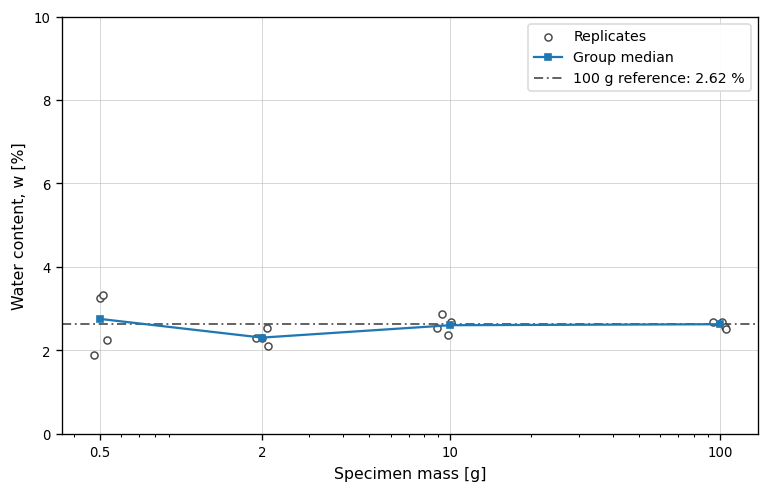

In [6]:
# Figure 3.1 — Individual water-content replicates with group median
x    = np.array(wc_levels)
y    = np.array([wc_median[L] for L in wc_levels])
yerr = np.array([wc_sd[L] for L in wc_levels])
rng = np.random.default_rng(42)

fig2_wc, ax = plt.subplots()
xs_all = np.array([r["mass_g"] for r in wc_results], float)
ys_all = np.array([r["w_pct"] for r in wc_results], float)
xs_jit = 10 ** (np.log10(xs_all) + rng.normal(0, 0.025, len(xs_all)))

ax.scatter(xs_jit, ys_all, s=18, facecolor="white", edgecolor="0.25", linewidth=0.9,
           alpha=0.95, label="Replicates", zorder=3)
ax.plot(x, y, marker="s", linestyle="-", color="tab:blue", lw=1.35, ms=3.4,
        markerfacecolor="tab:blue", markeredgecolor="tab:blue",
        label="Group median", zorder=4)
ax.axhline(wc_ref, color="0.35", ls=(0, (5, 2, 1, 2)), lw=1.1,
           label=f"100 g reference: {wc_ref:.2f} %")

ax.set_xscale("log")
ax.set_xticks(wc_levels)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Specimen mass [g]")
ax.set_ylabel("Water content, w [%]")
ax.set_ylim(0, 10)
ax.legend(frameon=True, facecolor="white", framealpha=0.94, edgecolor="0.85")
plt.tight_layout()
savefig(fig2_wc, "fig_3_1_water_content")
plt.show()


---
## 2. Particle Density by Water Pycnometer (ASTM D854)


### 2.1 Load and Clean Pycnometer Data


In [7]:
# Figure/Table input: processed pycnometer results.
df_pyk = pd.read_csv(DATA_DIR / "pycnometer_processed.csv").rename(columns={
    "temperature_C": "temp_C",
    "rho_s_g_cm3": "rho_s",
    "mass_g": "ms_g",
})
df_pyk["pyk_id"] = np.nan
df_pyk["fraction"] = (
    df_pyk["fraction"].astype(str)
    .str.replace(">75 um", ">75 µm", regex=False)
    .str.replace("<75 um", "<75 µm", regex=False)
)
for c in ["ms_g", "temp_C", "rho_s", "Gs"]:
    df_pyk[c] = pd.to_numeric(df_pyk[c], errors="coerce")

def nominal_mass_from_test_id(test_id):
    match = re.match(r"^(\d+(?:\.\d+)?)", str(test_id).strip().replace(",", "."))
    return float(match.group(1)) if match else np.nan

df_pyk["mass_g"] = df_pyk["test_id"].map(nominal_mass_from_test_id)
df_pyk["mass_label"] = df_pyk["mass_g"].apply(
    lambda v: f"{int(v)} g" if not pd.isna(v) and float(v).is_integer() else f"{v:g} g"
)
frac_order = {"Bulk": 0, ">75 µm": 1, "<75 µm": 2}
df_pyk = (
    df_pyk.assign(_fraction_order=df_pyk["fraction"].map(frac_order).fillna(99))
    .sort_values(["_fraction_order", "mass_g", "test_id"])
    .drop(columns="_fraction_order")
    .reset_index(drop=True)
)

display(df_pyk[["test_id", "mass_label", "fraction", "ms_g", "temp_C", "rho_s", "Gs"]])


,test_id,mass_label,fraction,ms_g,temp_C,rho_s,Gs
0,0.5A,0.5 g,Bulk,0.507,21.40,2.138600,2.139240
1,0.5B,0.5 g,Bulk,0.499,21.36,1.926060,1.926640
2,2A,2 g,Bulk,2.031,21.35,2.703580,2.704390
3,2B,2 g,Bulk,2.023,21.34,2.721980,2.722750
4,10A,10 g,Bulk,9.999,21.41,2.949540,2.950430
5,10B,10 g,Bulk,10.010,21.42,2.943230,2.944120
6,20A,20 g,Bulk,20.001,21.90,2.970260,2.971480
7,20B,20 g,Bulk,20.033,21.96,3.005310,3.006600
8,0.5C,0.5 g,>75 µm,0.604,21.10,2.287350,2.287880
9,2C,2 g,>75 µm,2.033,20.80,2.699410,2.699870


### 2.2 Summary Tables


In [8]:
# ── Bulk summary table ───────────────────────────────────────────────────────
bulk = df_pyk[df_pyk["fraction"] == "Bulk"].copy()

bulk_summary = (
    bulk.groupby("mass_g", as_index=False)
    .agg(n=("rho_s","count"), med_rho=("rho_s","median"),
         sd_rho=("rho_s","std"),  med_Gs=("Gs","median"), sd_Gs=("Gs","std"))
    .sort_values("mass_g")
)

ref_mass_pyk = bulk_summary["mass_g"].max()
ref_rho_pyk  = bulk_summary.loc[bulk_summary["mass_g"] == ref_mass_pyk, "med_rho"].iloc[0]
bulk_summary["delta_rho"] = (bulk_summary["med_rho"] - ref_rho_pyk).round(4)
bulk_summary["mass_label"] = bulk_summary["mass_g"].apply(
    lambda v: f"{int(v)} g" if float(v).is_integer() else f"{v:g} g"
)

print("Bulk summary (median-based):")
display(bulk_summary[["mass_label","n","med_rho","sd_rho","delta_rho","med_Gs","sd_Gs"]].rename(columns={
    "mass_label": "Specimen mass", "n": "n",
    "med_rho": "Median ρs [g/cm³]", "sd_rho": "SD ρs [g/cm³]",
    "delta_rho": "Δρs vs reference [g/cm³]",
    "med_Gs": "Median Gs [-]", "sd_Gs": "SD Gs [-]",
}).round(4))


Bulk summary (median-based):


,Specimen mass,n,Median ρs [g/cm³],SD ρs [g/cm³],Δρs vs reference [g/cm³],Median Gs [-],SD Gs [-]
0,0.5 g,2,2.0323,0.1503,-0.9555,2.0329,0.1503
1,2 g,2,2.7128,0.0130,-0.2750,2.7136,0.0130
2,10 g,2,2.9464,0.0045,-0.0414,2.9473,0.0045
3,20 g,2,2.9878,0.0248,0.0000,2.9890,0.0248


### 2.3 Thesis Figures


Saved: figures/fig_3_2_rho_s_bulk.pdf; Word SVG: figures_word/svg/fig_3_2_rho_s_bulk.svg; Word PNG: figures_word/png_450dpi/fig_3_2_rho_s_bulk.png


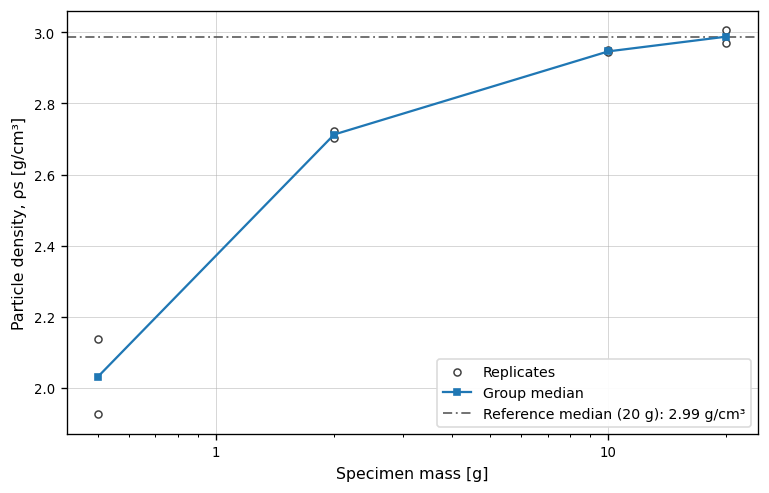

In [9]:
# ── Figure 3.2: Replicates + group median (bulk) ─────────────────────────────
fig1_pyk, ax = plt.subplots()
ax.scatter(bulk["mass_g"], bulk["rho_s"], s=18, facecolor="white", edgecolor="0.25",
           linewidth=0.9, label="Replicates", zorder=3)
ax.plot(bulk_summary["mass_g"], bulk_summary["med_rho"],
        marker="s", linestyle="-", color="tab:blue", lw=1.35, ms=3.4,
        markerfacecolor="tab:blue", markeredgecolor="tab:blue",
        label="Group median", zorder=4)
ax.axhline(ref_rho_pyk, color="0.35", ls=(0, (5, 2, 1, 2)), lw=1.1, alpha=0.9,
           label=f"Reference median ({ref_mass_pyk:g} g): 2.99 g/cm³")

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Specimen mass [g]")
ax.set_ylabel("Particle density, ρs [g/cm³]")
ax.legend(frameon=True, facecolor="white", framealpha=0.94, edgecolor="0.85")
plt.tight_layout()
savefig(fig1_pyk, "fig_3_2_rho_s_bulk")
plt.show()


> Figure 3.3 uses a black-and-white-readable style: each fraction has a distinct marker and line style in addition to colour.


In [10]:
# Fraction style shared by Figure 3.3.
FRACTION_STYLE = {
    "Bulk"   : {"marker": "s", "color": "tab:blue", "ls": "-",
                 "label": "Bulk"},
    ">75 µm" : {"marker": "^", "color": "tab:orange", "ls": (0,(6,2)),
                 "label": ">75 µm"},
    "<75 µm" : {"marker": "D", "color": "tab:green", "ls": (0,(1,1.5)),
                 "label": "<75 µm"},
}

def _frac_key(name):
    s = str(name).strip().lower()
    if "bulk" in s:
        return "Bulk"
    if ">75" in s or "over" in s or "coarse" in s:
        return ">75 µm"
    if "<75" in s or "under" in s or "fines" in s:
        return "<75 µm"
    return None


Saved: figures/fig_3_3_rho_s_fractions.pdf; Word SVG: figures_word/svg/fig_3_3_rho_s_fractions.svg; Word PNG: figures_word/png_450dpi/fig_3_3_rho_s_fractions.png


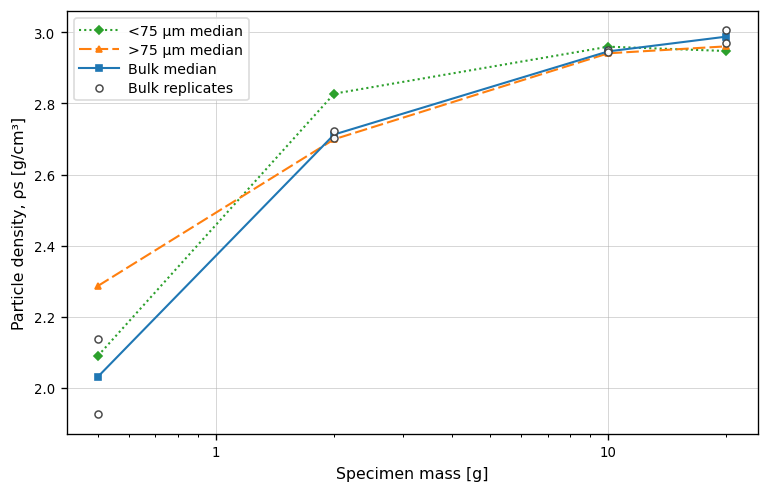

In [11]:
# ── Figure 3.3: all fractions + bulk replicates (B/W-readable) ────────────────
# Medians for all fractions + individual bulk replicate points. Bulk replicates are
# Shown as open circles so they are easy to distinguish from the median marker.
summary_all_pyk = (
    df_pyk.groupby(["fraction","mass_g"], as_index=False)
    .agg(n=("rho_s","count"), med_rho=("rho_s","median"), sd_rho=("rho_s","std"))
)

fig5_pyk, ax = plt.subplots()

for frac, sub in summary_all_pyk.groupby("fraction"):
    sub = sub.sort_values("mass_g")
    key = _frac_key(frac)
    st  = FRACTION_STYLE.get(key, {"marker":"D","color":"0.3","ls":":","label":str(frac)})
    ax.plot(sub["mass_g"], sub["med_rho"],
            marker=st["marker"], ls=st["ls"], color=st["color"],
            markerfacecolor=st["color"], markeredgecolor=st["color"],
            markersize=3.4, lw=1.25, label=f"{st['label']} median")

# Bulk replicates styled like Figure 3.2: hollow neutral circles.
bulk_rep = df_pyk[df_pyk["fraction"].str.strip().str.lower() == "bulk"].sort_values("mass_g")
ax.scatter(bulk_rep["mass_g"], bulk_rep["rho_s"],
           marker="o", s=18, facecolor="white",
           edgecolor="0.25", linewidth=0.9,
           alpha=0.95, label="Bulk replicates", zorder=2)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Specimen mass [g]")
ax.set_ylabel("Particle density, ρs [g/cm³]")
ax.legend(frameon=True, facecolor="white", framealpha=0.92, edgecolor="0.85", handlelength=2.8, labelspacing=0.35, handletextpad=0.65)
plt.tight_layout()
savefig(fig5_pyk, "fig_3_3_rho_s_fractions")
plt.show()


### Figure 4.1 - Mineralogical Plausibility Check
This discussion figure belongs with the particle-density results and is therefore placed here.


Saved: figures/fig_4_1_rho_s_plausibility.pdf; Word SVG: figures_word/svg/fig_4_1_rho_s_plausibility.svg; Word PNG: figures_word/png_450dpi/fig_4_1_rho_s_plausibility.png


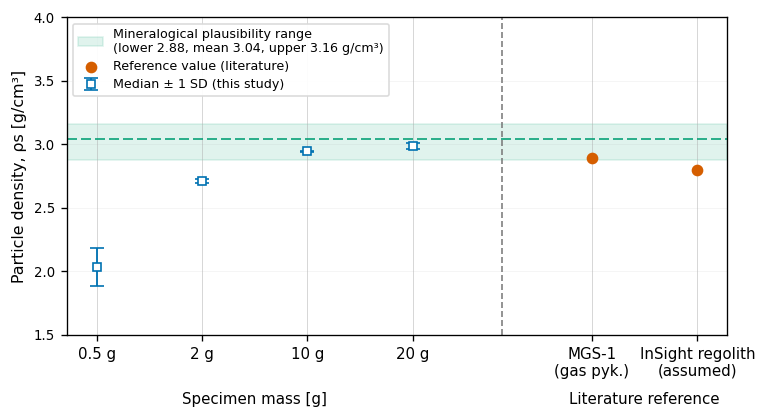

In [12]:
# Figure 4.1 - Mineralogical plausibility of bulk particle density.
RHO_MIN_LOWER = 2.88
RHO_MIN_MEAN  = 3.04
RHO_MIN_UPPER = 3.16

literature_refs = [
    ("MGS-1\n(gas pyk.)",           2.89, None, "Karacasulu et al. 2025"),
    ("InSight regolith\n(assumed)", 2.80, None, "Morgan et al. 2018"),
]

YLIM = (1.5, 4.0)
n_meas = len(bulk_summary)
n_lit  = len(literature_refs)
GAP = 0.7

x_meas = np.arange(n_meas, dtype=float)
x_lit  = np.arange(n_lit, dtype=float) + n_meas + GAP
x_div  = n_meas - 0.5 + GAP/2

fig6_pyk, ax = plt.subplots(figsize=(WORD_TEXT_WIDTH_IN, 3.6))

ax.axhspan(RHO_MIN_LOWER, RHO_MIN_UPPER, color="#009E73", alpha=0.12,
           label=(f"Mineralogical plausibility range\n"
                  f"(lower {RHO_MIN_LOWER}, mean {RHO_MIN_MEAN}, "
                  f"upper {RHO_MIN_UPPER} g/cm³)"))
ax.axhline(RHO_MIN_MEAN, color="#009E73", ls=(0, (5, 2)), lw=1.2, alpha=0.8)

ax.errorbar(
    x_meas, bulk_summary["med_rho"], yerr=bulk_summary["sd_rho"],
    fmt="s", markersize=5.2, color="#0072B2", markerfacecolor="white",
    markeredgecolor="#0072B2", capsize=4, lw=1.1, zorder=4,
    label="Median ± 1 SD (this study)"
)

for xi, (_label, val, err, _source) in zip(x_lit, literature_refs):
    if err is not None:
        ax.errorbar(xi, val, yerr=err, fmt="o",
                    color="#D55E00", markersize=6,
                    capsize=4, lw=1.1, zorder=3)
    else:
        ax.scatter(xi, val, marker="o", s=36, color="#D55E00", zorder=3)
ax.scatter([], [], marker="o", s=36, color="#D55E00",
           label="Reference value (literature)")

meas_labels = list(bulk_summary["mass_label"])
lit_labels = [label for (label, _, _, _) in literature_refs]
ax.set_xticks(list(x_meas) + list(x_lit))
ax.set_xticklabels(meas_labels + lit_labels, fontsize=9)

ax.axvline(x_div, color="0.45", ls=(0, (4, 2)), lw=0.9, zorder=2)
ax.text(np.mean(x_meas), -0.18, "Specimen mass [g]", ha="center", va="top",
        fontsize=9, transform=ax.get_xaxis_transform())
ax.text(np.mean(x_lit), -0.18, "Literature reference", ha="center", va="top",
        fontsize=9, transform=ax.get_xaxis_transform())

ax.set_ylim(*YLIM)
ax.set_ylabel("Particle density, ρs [g/cm³]")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.94,
          edgecolor="0.85", fontsize=7.6, ncol=1)

plt.tight_layout()
savefig(fig6_pyk, "fig_4_1_rho_s_plausibility")
plt.show()


In [13]:
# Keep the compact Word-width style from Section 0.1 for all subsequent figures.
# This cell is intentionally left as a style checkpoint for the PSD section.
apply_style()

---
## 3. Particle-Size Distribution (ASTM D6913 + ASTM D7928)


In [14]:
# ── PSD configuration ───────────────────────────────────────────────────────
PLOT_CFG = {
    "xlim_full"           : (0.001, 14.0),
    "xlim_sieve"          : (0.025, 10.0),
    "xlim_hydro"          : (0.001, 0.075),
    "ylim"                : (0, 105),
    # Default PSD figure size. (14, 8) is a good compromise: tall enough to read
    # the USCS header, fraction names, and legend without stretching the curves.
    # (13, 10) is too vertically dominant and makes the legend harder to place.
    # Scenario E uses its own figure size where needed.
    "figsize"             : (WORD_TEXT_WIDTH_IN, 3.85),
    "show_overlay"        : True,
    "show_uscs"           : True,
    "show_sieve_openings" : True,
    "show_mgs1"           : False,
    "show_envelopes"      : False,
    "mgs1_auto_expand"    : True,
    "fines_end"           : 0.075,
    "sand_end"            : 4.75,
    "legend_loc"          : "lower right",
    "grid_alpha"          : 0.40,
    "reference_hydros"    : ("50A", "50B"),
    "reference_sieves"    : ("100W1", "100W2", "50W1", "50W2"),
}

# ── PSD-specific styling (built from mass-centric scheme) ────────────────────
# Each key maps to a style dict that plot_psd understands.
# Method inferred from key: 'W' → wet, 'F' prefix → fines-only hydro, else dry/bulk-hydro.

def make_psd_style(key, kind_override=None):
    """Build a style dict for a single PSD curve based on its test ID.
    kind_override: 'dry' | 'wet' | 'hydro_bulk' | 'hydro_fines' | None (auto)
    """
    mass = parse_mass(key)
    rep  = parse_rep_idx(key)
    s = str(key)
    if kind_override:
        method = kind_override
    elif s.startswith("F"):
        method = "hydro_fines"
    elif "W" in s:
        method = "wet"
    else:
        method = "dry"   # used for dry sieve and bulk hydro; call context distinguishes them
    return style_for(mass, method=method, replicate_idx=rep)

LINE_KW = {"linewidth": 1.0, "markersize": 3.0}
MGS1_MM = {"D10": 0.00519, "D30": 0.01996, "D50": 0.04930,
            "D60": 0.06685, "D90": 0.20548}

ENVELOPE_LABELS = {
    "A": "(A) Phoenix fines\n(Delage et al. (2022); Goetz et al. (2010))",
    "B": "(B) Active sands (Gale/Bagnold)\n(Golombek et al. (2020); Weitz et al. (2018))",
    "C": "(C) Armored/coarse lag\n(Blake et al. (2013); Weitz et al. (2018))",
}

# STYLE dict brukes av plot_psd (bakoverkompatibelt med gamle kall).
# Bygges automatisk fra make_psd_style() for alle test-ID-er.
STYLE = {}
for _key in ["50A","50B","10A","10B","2A","2B","0.5A","0.5B"]:
    STYLE[_key] = make_psd_style(_key, kind_override="dry")
for _key in ["100W1","100W2","50W1","50W2","10W1","10W2","10W3",
             "2W1","2W2","2W3","0.5W1","0.5W2","0.5W3"]:
    STYLE[_key] = make_psd_style(_key, kind_override="wet")
for _key in ["F0.5","F2","F10","F50"]:
    STYLE[_key] = make_psd_style(_key, kind_override="hydro_fines")


In [15]:
# ── Overlay and annotation functions ────────────────────────────────────────

def add_uscs_header(ax, xlim, yband=(1.105, 1.175)):
    """USCS classification header above the PSD axes."""
    fines_end = PLOT_CFG["fines_end"]
    sand_end  = PLOT_CFG["sand_end"]
    lo, hi    = min(xlim), max(xlim)
    trans     = ax.get_xaxis_transform()
    y0, y1    = yband

    ax.add_patch(Rectangle((lo, y0), hi - lo, y1 - y0, transform=trans,
                            facecolor="white", edgecolor="0.75", lw=1.0,
                            clip_on=False, zorder=8))
    for label, xl, xr in [("FINES (silt + clay)", lo, fines_end),
                           ("SAND",                fines_end, sand_end),
                           ("GRAVEL",              sand_end, hi)]:
        xl_c = max(xl, lo); xr_c = min(xr, hi)
        if xr_c <= xl_c: continue
        ax.add_patch(Rectangle((xl_c, y0), xr_c - xl_c, y1 - y0, transform=trans,
                                facecolor="#f6f6f6", edgecolor="0.35", lw=1.0,
                                clip_on=False, zorder=9))
        xm = 10 ** ((np.log10(xl_c) + np.log10(xr_c)) / 2)
        ax.text(xm, (y0 + y1) / 2, label, ha="center", va="center",
                fontsize=6.2, transform=trans, zorder=10, clip_on=False)
    for xv in [fines_end, sand_end]:
        if lo < xv < hi:
            ax.axvline(xv, color="0.45", lw=0.7, alpha=0.65, zorder=0)

    # "USCS:" label just above the band — normal black text
    ax.text(0.002, y1 + 0.01, "USCS:",
            ha="left", va="bottom", fontsize=6.2,
            transform=ax.transAxes, zorder=11, clip_on=False)

def add_sieve_ticks(ax, sieve_mm, label_prefix="Sieve openings:"):
    """Sieve-opening tick marks on a secondary top axis."""
    ticks  = [float(t) for t in sieve_mm if t > 0]
    labels = [f"{t:g} mm" if t >= 1 else f"{int(round(t*1000))} µm" for t in ticks]
    ax_top = ax.twiny()
    ax_top.set_xscale("log")
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(ticks)
    ax_top.set_xticklabels(labels, fontsize=5.8)
    ax_top.tick_params(axis="x", which="both", length=3, pad=0)
    for sp in ax_top.spines.values(): sp.set_visible(False)
    ax_top.text(0.0, 1.015, label_prefix,
                transform=ax_top.transAxes, fontsize=5.8, va="bottom")
    return ax_top

def add_mgs1(ax, show=True,
             label="MGS-1 percentiles (Long-Fox & Britt (2023))"):
    """MGS-1 percentile markers connected by a line with D-value labels."""
    if not show: return
    xs     = np.array(list(MGS1_MM.values()))
    ys     = np.array([int(k[1:]) for k in MGS1_MM])
    xmin, xmax = ax.get_xlim()
    lo, hi = min(xmin, xmax), max(xmin, xmax)
    if PLOT_CFG["mgs1_auto_expand"]:
        lo = min(lo, xs.min() * 0.85); hi = max(hi, xs.max() * 1.15)
        ax.set_xlim(lo, hi)
    vis = (xs >= lo) & (xs <= hi)
    ax.semilogx(xs[vis], ys[vis], color="black", lw=1.2,
                marker="o", ms=4.0, markerfacecolor="black",
                label=label, zorder=11)
    for d_key, d_val in MGS1_MM.items():
        y_val = int(d_key[1:])
        if lo <= d_val <= hi:
            ax.annotate(d_key, xy=(d_val, y_val),
                        xytext=(-4, 4), textcoords="offset points",
                        ha="right", fontsize=6.6, fontweight="bold", zorder=12)

def add_mars_envelopes(ax, show=True, full_labels=False):
    """Mars soil particle-size envelopes as background bands."""
    if not show: return
    x       = np.logspace(np.log10(0.001), np.log10(6.0), 600)
    anchors = np.array([0.002, 0.010, 0.050, 0.150, 0.500, 2.000, 5.000])
    env_data = {
        "A": (np.array([2,10,40,80,98,100,100]), np.array([5,20,60,95,100,100,100])),
        "B": (np.array([0,2,35,65,90,99,100]),   np.array([1,5,45,80,97,100,100])),
        "C": (np.array([0,0,10,30,60,90,97]),    np.array([0,1,20,45,80,98,99])),
    }
    colors = {"A": "#f0f0f0", "B": "#cfcfcf", "C": "#a6a6a6"}
    edgecols = {"A": "0.42", "B": "0.28", "C": "0.14"}
    # Subtle hatch patterns: vertical, horizontal, and diagonal; different density.
    hatches = {"A": "|||", "B": "---", "C": "////"}
    edge_lw = {"A": 0.24, "B": 0.22, "C": 0.20}
    alphas = {"A": 0.30, "B": 0.28, "C": 0.26}
    for key, (y_lo, y_hi) in env_data.items():
        ylo = np.interp(np.log10(x), np.log10(anchors), y_lo)
        yhi = np.interp(np.log10(x), np.log10(anchors), y_hi)
        lbl = ENVELOPE_LABELS[key] if full_labels else f"({key})"
        ax.fill_between(x, ylo, yhi, alpha=alphas[key], color=colors[key],
                        edgecolor=edgecols[key], linewidth=edge_lw[key],
                        hatch=hatches[key], label=lbl, zorder=1)

def setup_psd_ax(ax, xlim=None, ylim=None,
                 xlabel="Particle diameter [mm]",
                 ylabel="Cumulative percent passing [%]"):
    """Configure log x-scale axis with standard PSD labels."""
    xlim = PLOT_CFG["xlim_full"] if xlim is None else xlim
    ylim = PLOT_CFG["ylim"]      if ylim  is None else ylim
    ax.set_xscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    major_ticks = [0.001, 0.01, 0.1, 1, 10]
    ax.set_xticks([t for t in major_ticks if min(xlim) <= t <= max(xlim)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=PLOT_CFG["grid_alpha"])

def apply_psd_overlay(ax, xlim=None, sieve_mm=None, sieve_label="Sieve openings:"):
    """Add USCS header and sieve-opening ticks.
    Pass sieve_mm to override the default experimental sieves (e.g. ASTM sieves).
    """
    xlim    = ax.get_xlim() if xlim is None else xlim
    _sieves = SIEVES_MM[SIEVES_MM > 0] if sieve_mm is None else np.asarray(sieve_mm)
    if PLOT_CFG.get("show_sieve_openings", True):
        ticks_in = [t for t in _sieves if min(xlim) <= t <= max(xlim)]
        if ticks_in: add_sieve_ticks(ax, ticks_in, label_prefix=sieve_label)
    if PLOT_CFG.get("show_uscs", True):
        add_uscs_header(ax, xlim)



def apply_fines_overlay(ax, xlim=None):
    """Add the fines and visible sand PSD overlay for hydrometer-only plots."""
    xlo = ax.get_xlim()[0] if xlim is None else min(xlim)
    xhi = ax.get_xlim()[1] if xlim is None else max(xlim)
    if PLOT_CFG.get("show_sieve_openings", True):
        add_sieve_ticks(ax, [PLOT_CFG["fines_end"]], label_prefix="Sieve opening:")
    if PLOT_CFG.get("show_uscs", True):
        # Lower than the full-PSD header so fixed-canvas hydrometer exports retain it.
        add_uscs_header(ax, (xlo, xhi), yband=(1.065, 1.135))

def legend_clean(ax, fontsize=None, loc=None, **kwargs):
    """Consistent compact legend that avoids oversized handles in PSD figures."""
    opts = dict(frameon=True, facecolor="white", framealpha=0.94, edgecolor="0.85",
                handlelength=2.6, handletextpad=0.50, borderpad=0.28,
                borderaxespad=0.25, labelspacing=0.28, columnspacing=0.75,
                numpoints=1, markerfirst=True)
    if fontsize is not None:
        opts["fontsize"] = fontsize
    if loc is not None:
        opts["loc"] = loc
    opts.update(kwargs)
    return ax.legend(**opts)


### 3.1 Sieve and Hydrometer Input Data


In [16]:
# Figure/Table input: dry and wet-prepared sieve retained masses.
SIEVES_MM = np.array([2.0, 1.0, 0.5, 0.25, 0.125, 0.075, 0.0])

def load_sieve_retained(filename):
    raw = pd.read_csv(DATA_DIR / filename)
    out = {}
    for test_id, sub in raw.groupby("test_id", sort=False):
        sub = sub.sort_values("sieve_order")
        out[test_id] = sub["retained_g"].to_numpy(float)
    return out

PSD_DATA = {}
PSD_DATA.update(load_sieve_retained("dry_sieve_raw.csv"))
PSD_DATA.update(load_sieve_retained("wet_sieve_raw.csv"))

# Figure/Table input: bulk hydrometer readings.
hydro_raw = pd.read_csv(DATA_DIR / "hydrometer_bulk_raw.csv")
PSD_HYDRO_RUNS = {
    test_id: {
        "wet_mass_g": float(sub["wet_mass_g"].iloc[0]),
        "data": list(sub[["t_min", "H", "T_C"]].itertuples(index=False, name=None)),
    }
    for test_id, sub in hydro_raw.groupby("test_id", sort=False)
}

hydro_params = pd.read_csv(DATA_DIR / "hydrometer_constants.csv").set_index("parameter")["value"]
HYD_RHO_S = float(hydro_params["rho_s_hydro"])
HYD_WC_PCT = float(hydro_params["water_content_hydro_pct"])


### 3.2 Hydrometer Calculations


In [17]:
def load_hydro_constants(path):
    values = pd.read_csv(path).set_index("parameter")["value"].to_dict()
    return {k: float(v) for k, v in values.items()}

def wet_to_dry(wet_g, wc_pct):
    return wet_g * 100.0 / (100.0 + wc_pct)

def Lcorr(T_C, c):
    return c["B_152"] - c["a1"] * T_C - c["a2"] * T_C**2

def Leff(H, c):
    return (c["R36"]
            + (c["R35"] - c["R36"]) / (c["U36"] - c["U35"]) * (c["U36"] - H + c["O37"])
            - c["O35"] / (2 * c["O36"]))

def D_mm(t_min, H, Gs_T, c):
    if t_min <= 0:
        return np.nan
    denom = c["rho_w"] * c["g"] * (Gs_T - 1.0) * t_min * 60.0
    return np.sqrt(18.0 * c["mu"] * Leff(H, c) / denom) * 10.0 if denom > 0 else np.nan

def pct_finer_raw(t_min, H, T_C, Md_g, Gs_T, c):
    if Md_g <= 0:
        return np.nan
    Lc = Lcorr(T_C, c)
    return c["coef_pct"] * (Gs_T / (Gs_T - 1.0)) * (1000.0 / Md_g) * (H - Lc)

def compute_hydro_run(name, run_data, wc_pct, rho_s, constants):
    Md = wet_to_dry(run_data["wet_mass_g"], wc_pct)
    Gs_T = rho_s / constants["rho_w"]
    rows = []
    for (t, H, T) in run_data["data"]:
        rows.append({
            "test": name, "t_min": t, "H": H, "T_C": T, "Md_g": Md, "Gs_T": Gs_T,
            "Lcorr": Lcorr(T, constants),
            "D_mm": D_mm(t, H, Gs_T, constants),
            "%finer_raw": pct_finer_raw(t, H, T, Md, Gs_T, constants),
        })
    df = pd.DataFrame(rows).sort_values("D_mm", ascending=False).reset_index(drop=True)
    df["%finer"] = df["%finer_raw"].clip(0, 100)
    df["over_100"] = df["%finer_raw"] > 100
    df["signal"] = df["H"] - df["Lcorr"]
    df["low_signal"] = df["signal"] < 0.5
    return df

HYDRO_CONST = load_hydro_constants(DATA_DIR / "hydrometer_astm152h_constants.csv")
HYDRO_WITH = {
    k: compute_hydro_run(k, v, HYD_WC_PCT, HYD_RHO_S, HYDRO_CONST)
    for k, v in PSD_HYDRO_RUNS.items()
}
print("Bulk hydrometer runs:", list(HYDRO_WITH.keys()))


Bulk hydrometer runs: ['50A', '50B', '10A', '10B', '2A', '2B', '0.5A', '0.5B']


### 3.3 Curve-Building and Gradation Metrics


In [18]:
# ── Sieve curve from retained mass ───────────────────────────────────────────────
def sieve_curve(key):
    """Return (d_mm, pct_finer, total_g) for a sieve test."""
    ret   = np.asarray(PSD_DATA[key], float)
    total = ret.sum()
    cum   = np.cumsum(ret)
    mask  = SIEVES_MM > 0
    x = SIEVES_MM[mask]
    y = 100 * (1 - cum[mask] / total)
    return x, y, total

def p075(key):
    """Fraction finer than 0.075 mm for a sieve test."""
    _, y, _ = sieve_curve(key)
    return float(y[-1])

def hydro_curve(key, src=None, y_col="%finer", clip=True,
                upper_bound=None, monotonic=False):
    """Return (d_mm, pct_finer) for a hydrometer test.

    The default returns the plotted hydrometer values. For stitched full PSD
    curves, pass upper_bound=P0.075 and monotonic=True so the hydrometer branch
    cannot exceed the measured sieve fines content or decrease with increasing
    particle diameter.
    """
    src = HYDRO_WITH if src is None else src
    df  = src[key]
    d   = pd.to_numeric(df["D_mm"], errors="coerce").to_numpy(float)
    if y_col not in df:
        y_col = "%finer"
    p   = pd.to_numeric(df[y_col], errors="coerce").to_numpy(float)
    m   = np.isfinite(d) & np.isfinite(p) & (d > 0)
    d, p = d[m], p[m]
    idx  = np.argsort(d)
    d, p = d[idx], p[idx]
    if clip:
        p = np.clip(p, 0, 100)
    if upper_bound is not None:
        p = np.minimum(p, upper_bound)
    if monotonic and len(p):
        p = np.maximum.accumulate(p)
    return d, p

def D_at_pct(d_mm, p_finer, target):
    """Interpolate particle diameter at a given percent finer."""
    d, p = np.asarray(d_mm, float), np.asarray(p_finer, float)
    m    = np.isfinite(d) & np.isfinite(p) & (d > 0)
    d, p = d[m], p[m]
    if len(d) < 2: return np.nan
    idx  = np.argsort(d)
    d, p = d[idx], p[idx]
    if p[0] > p[-1]: p = 100.0 - p
    if target < p.min() or target > p.max(): return np.nan
    return 10 ** np.interp(target, p, np.log10(d))

def gradation_metrics(d_mm, p_finer):
    """Compute D10, D30, D50, D60, D90, Cu and Cc."""
    D = {f"D{n}": D_at_pct(d_mm, p_finer, n) for n in [10, 30, 50, 60, 90]}
    D10, D30, D60 = D["D10"], D["D30"], D["D60"]
    Cu = D60 / D10 if all(np.isfinite([D10, D60])) and D10 > 0 else np.nan
    Cc = D30**2 / (D10 * D60) if all(np.isfinite([D10, D30, D60])) and D10*D60 > 0 else np.nan
    return {**D, "Cu": Cu, "Cc": Cc}

def stitch_psd(hydro_key, sieve_key, P075_val=None):
    """Combine hydrometer and sieve curves into a full PSD.

    This keeps the original hydrometer percent-finer values. It is appropriate
    for the 50 g and 10 g stitched curves, but low-mass diagnostic curves are
    handled separately in Figure 3.16 because their hydrometer readings are not
    quantitatively reliable.
    """
    if P075_val is None: P075_val = p075(sieve_key)
    x_s, y_s, _ = sieve_curve(sieve_key)
    y_s          = y_s.copy(); y_s[-1] = P075_val
    d_h, p_h     = hydro_curve(hydro_key)
    keep         = d_h < PLOT_CFG["fines_end"]
    d_h, p_h     = d_h[keep], p_h[keep]
    d_all = np.concatenate([d_h, [PLOT_CFG["fines_end"]], x_s])
    p_all = np.concatenate([p_h, [P075_val], y_s])
    df    = pd.DataFrame({"d_mm": d_all, "p": p_all}).dropna()
    df    = df.sort_values("d_mm").drop_duplicates("d_mm", keep="first")
    return df["d_mm"].to_numpy(float), df["p"].to_numpy(float)

def interp_to_grid(d_mm, p, grid):
    d, y = np.asarray(d_mm, float), np.asarray(p, float)
    m    = np.isfinite(d) & np.isfinite(y) & (d > 0)
    d, y = d[m], y[m]
    if len(d) < 2: return np.full_like(grid, np.nan, float)
    idx  = np.argsort(d)
    return np.interp(np.log10(grid), np.log10(d[idx]), np.clip(y[idx], 0, 100),
                     left=np.nan, right=np.nan)


### 3.4 Plotting Helpers


In [19]:
# ── Generic PSD plotting function ────────────────────────────────────────────
def plot_psd(curves, xlim=None, ylim=None,
             show_overlay=None, show_mgs1=None, show_envelopes=None):
    """Plot one or more PSD curves."""
    cfg            = PLOT_CFG
    show_overlay   = cfg["show_overlay"]   if show_overlay   is None else show_overlay
    show_mgs1      = cfg["show_mgs1"]      if show_mgs1      is None else show_mgs1
    show_envelopes = cfg["show_envelopes"] if show_envelopes is None else show_envelopes

    fig, ax = plt.subplots(figsize=cfg.get("figsize", plt.rcParams["figure.figsize"]))
    add_mars_envelopes(ax, show=show_envelopes, full_labels=show_envelopes)

    for c in curves:
        style_key = c.get("style_key", c["label"])
        st = {**LINE_KW, **STYLE.get(style_key, {}), **c.get("style", {})}
        ax.semilogx(c["d_mm"], c["p"], label=c["label"], **st)

    setup_psd_ax(ax, xlim=xlim, ylim=ylim)
    add_mgs1(ax, show=show_mgs1)
    if show_overlay:
        apply_psd_overlay(ax)

    legend_clean(ax, loc=cfg["legend_loc"], handlelength=2.8)
    plt.tight_layout()
    return fig, ax

def plot_sieve(keys, xlim=None, ylim=None,
               show_overlay=None, show_mgs1=None, show_envelopes=None):
    """Plot sieve curves for the given test IDs."""
    curves = [{"label": specimen_label(k, "wet" if "W" in str(k) else "dry"),
               "style_key": k,
               "d_mm": sieve_curve(k)[0], "p": sieve_curve(k)[1]} for k in keys]
    return plot_psd(curves, xlim=xlim or PLOT_CFG["xlim_sieve"],
                    ylim=ylim, show_overlay=show_overlay,
                    show_mgs1=show_mgs1, show_envelopes=show_envelopes)

def plot_hydrometer(keys, xlim=None, ylim=None,
                    show_overlay=None, show_mgs1=None, show_envelopes=None):
    """Plot hydrometer curves for the given test IDs."""
    curves = [{"label": specimen_label(k, "hydro_bulk"), "style_key": k,
               "d_mm": hydro_curve(k)[0], "p": hydro_curve(k)[1],
               "style": {"linestyle": REPLICATE_LS.get(parse_rep_idx(k), "-"), "alpha": 0.9}}
              for k in keys]
    return plot_psd(curves, xlim=xlim or PLOT_CFG["xlim_hydro"],
                    ylim=ylim, show_overlay=show_overlay,
                    show_mgs1=show_mgs1, show_envelopes=show_envelopes)

def plot_stitched(combos, xlim=None, ylim=None,
                  show_overlay=None, show_mgs1=None, show_envelopes=None):
    """Plot combined (stitched) PSD curves."""
    curves = []
    for hk, sk, P075, lbl in combos:
        d, p = stitch_psd(hk, sk, P075)
        curves.append({"label": lbl, "style_key": hk, "d_mm": d, "p": p})
    return plot_psd(curves, xlim=xlim or PLOT_CFG["xlim_full"],
                    ylim=ylim, show_overlay=show_overlay,
                    show_mgs1=show_mgs1, show_envelopes=show_envelopes)

def plot_sieve_group_medians(groups, xlim=None, ylim=None, band=None,
                              show_overlay=None, show_mgs1=None, show_envelopes=None):
    """Plot median PSD per group with optional min-max band."""
    cfg            = PLOT_CFG
    show_overlay   = cfg["show_overlay"]   if show_overlay   is None else show_overlay
    show_mgs1      = cfg["show_mgs1"]      if show_mgs1      is None else show_mgs1
    show_envelopes = cfg["show_envelopes"] if show_envelopes is None else show_envelopes

    fig, ax = plt.subplots(figsize=cfg.get("figsize", plt.rcParams["figure.figsize"]))
    add_mars_envelopes(ax, show=show_envelopes, full_labels=show_envelopes)

    for grp_label, keys in groups.items():
        x_ref, Y = None, []
        for k in keys:
            x, y, _ = sieve_curve(k)
            if x_ref is None:
                x_ref = x
            Y.append(y)
        Y     = np.vstack(Y)
        y_med = np.nanmedian(Y, axis=0)
        base_st = {**LINE_KW, **STYLE.get(keys[0], {})}
        base_st.update({"linewidth": 1.05, "markersize": 3.1})
        color   = base_st.get("color", None)
        ax.plot(x_ref, y_med, label=grp_label, **base_st)
        if band == "minmax":
            ax.fill_between(x_ref, Y.min(0), Y.max(0), alpha=0.12, color=color)
        elif band == "iqr":
            ax.fill_between(x_ref, np.nanpercentile(Y,25,0),
                            np.nanpercentile(Y,75,0), alpha=0.12, color=color)

    setup_psd_ax(ax, xlim=xlim or PLOT_CFG["xlim_sieve"], ylim=ylim)
    add_mgs1(ax, show=show_mgs1)
    if show_overlay:
        apply_psd_overlay(ax)

    legend_clean(ax, loc=cfg["legend_loc"], handlelength=2.8)
    plt.tight_layout()
    return fig, ax

def add_psd_zoom_inset(ax, xlim=(0.070, 0.140), loc="lower right", bbox=(0.64, 0.045, 0.30, 0.65)):
    """Add a tall fine-end inset using the already plotted PSD curves."""
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    axins = inset_axes(ax, width="100%", height="100%", loc=loc,
                       bbox_to_anchor=bbox, bbox_transform=ax.transAxes, borderpad=0)
    y_zoom = (36, 62)
    for line in ax.get_lines():
        label = line.get_label()
        if label.startswith("_") or "MGS-1" in label:
            continue
        xd = np.asarray(line.get_xdata(), float)
        yd = np.asarray(line.get_ydata(), float)
        mask = np.isfinite(xd) & np.isfinite(yd) & (xd >= xlim[0]) & (xd <= xlim[1])
        if mask.sum() == 0:
            continue
        axins.semilogx(xd, yd, color=line.get_color(), linestyle=line.get_linestyle(),
                       linewidth=max(0.85, line.get_linewidth()*0.95),
                       marker=line.get_marker(), markersize=max(2.1, line.get_markersize()*0.9),
                       markerfacecolor=line.get_markerfacecolor(), markeredgecolor=line.get_markeredgecolor(),
                       markeredgewidth=line.get_markeredgewidth(), alpha=line.get_alpha() or 1.0)
    axins.set_xlim(*xlim)
    axins.set_ylim(*y_zoom)
    axins.set_xscale("log")
    axins.set_xticks([0.075, 0.125])
    axins.set_xticklabels(["75 µm", "125 µm"], fontsize=5.2)
    axins.xaxis.set_minor_formatter(mticker.NullFormatter())
    axins.tick_params(axis="both", labelsize=5.2, length=2, pad=1)
    axins.grid(True, which="both", alpha=0.22)
    axins.set_facecolor("white")
    for spine in axins.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor("0.25")
    # Draw only the zoomed data window on the parent axis, without connector lines.
    rect = Rectangle((xlim[0], y_zoom[0]), xlim[1] - xlim[0], y_zoom[1] - y_zoom[0],
                     fill=False, edgecolor="0.35", linewidth=0.75, zorder=8)
    ax.add_patch(rect)
    return axins

def build_reference_ensemble(hydro_keys=None, sieve_keys=None):
    """Build all reference stitched PSD scenarios."""
    h_keys = PLOT_CFG["reference_hydros"] if hydro_keys is None else hydro_keys
    s_keys = PLOT_CFG["reference_sieves"] if sieve_keys is None else sieve_keys
    scenarios = []
    for h in h_keys:
        for s in s_keys:
            P075_val = p075(s)
            d, p_    = stitch_psd(h, s, P075_val)
            scenarios.append({"hydro": h, "sieve": s, "P075": P075_val, "d_mm": d, "p": p_})
    return scenarios

def plot_reference_band(scenarios, xlim=None, ylim=None, show_median=True,
                        show_overlay=None, show_mgs1=None, show_envelopes=None):
    """Plot min-max band from reference scenarios with optional median."""
    cfg = PLOT_CFG
    xlim = xlim or cfg["xlim_full"]; ylim = ylim or cfg["ylim"]
    show_overlay   = cfg["show_overlay"]   if show_overlay   is None else show_overlay
    show_mgs1      = cfg["show_mgs1"]      if show_mgs1      is None else show_mgs1
    show_envelopes = cfg["show_envelopes"] if show_envelopes is None else show_envelopes

    grid = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 500)
    Y    = np.vstack([interp_to_grid(sc["d_mm"], sc["p"], grid) for sc in scenarios])

    fig, ax = plt.subplots(figsize=cfg.get("figsize", plt.rcParams["figure.figsize"]))
    add_mars_envelopes(ax, show=show_envelopes, full_labels=show_envelopes)
    ax.fill_between(grid, np.nanmin(Y,0), np.nanmax(Y,0), alpha=0.26, color="0.70", hatch="///",
                    edgecolor="0.45", linewidth=0.35, label="Min–max band")
    if show_median:
        ax.semilogx(grid, np.nanmedian(Y,0), lw=1.4, color="0.15", linestyle="-", label="Median")

    setup_psd_ax(ax, xlim=xlim, ylim=ylim)
    add_mgs1(ax, show=show_mgs1)
    if show_overlay:
        apply_psd_overlay(ax)

    legend_clean(ax, loc=cfg["legend_loc"], handlelength=2.8)
    plt.tight_layout()
    return fig, ax


### 3.5 Dry Sieving


Saved: figures/fig_3_5_dry_sieve_2_05.pdf; Word SVG: figures_word/svg/fig_3_5_dry_sieve_2_05.svg; Word PNG: figures_word/png_450dpi/fig_3_5_dry_sieve_2_05.png


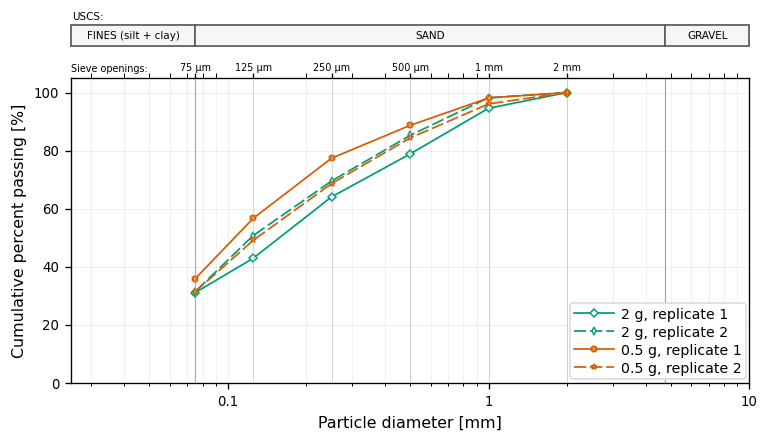

In [20]:
# ── Figure: Small dry sieve specimens ─────────────────────────────────────
SMALL_DRY = ["2A", "2B", "0.5A", "0.5B"]
SIEVE_XLIM = PLOT_CFG["xlim_sieve"]
fig, ax = plot_sieve(SMALL_DRY, xlim=SIEVE_XLIM)
savefig(fig, "fig_3_5_dry_sieve_2_05")
plt.show()


Saved: figures/fig_3_4_dry_sieve_50_10.pdf; Word SVG: figures_word/svg/fig_3_4_dry_sieve_50_10.svg; Word PNG: figures_word/png_450dpi/fig_3_4_dry_sieve_50_10.png


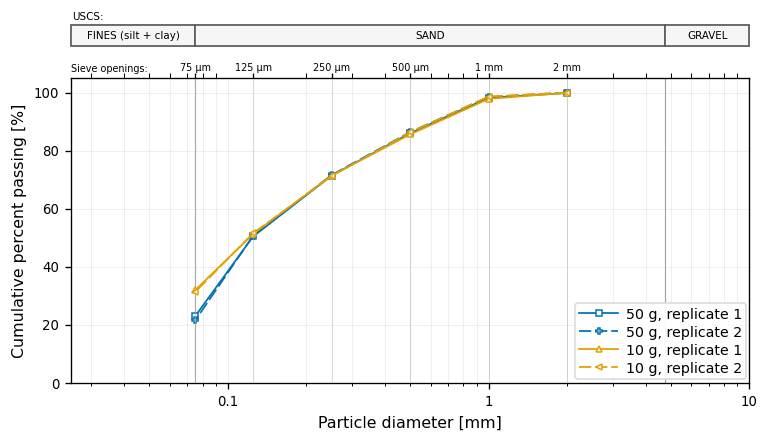

In [21]:
# ── Figure: Big dry sieve specimens ─────────────────────────────────────────
BIG_DRY = ["50A", "50B", "10A", "10B"]
SIEVE_XLIM = PLOT_CFG["xlim_sieve"]
fig, ax = plot_sieve(BIG_DRY, xlim=SIEVE_XLIM)
savefig(fig, "fig_3_4_dry_sieve_50_10")
plt.show()


Saved: figures/fig_3_6_dry_sieve_medians.pdf; Word SVG: figures_word/svg/fig_3_6_dry_sieve_medians.svg; Word PNG: figures_word/png_450dpi/fig_3_6_dry_sieve_medians.png


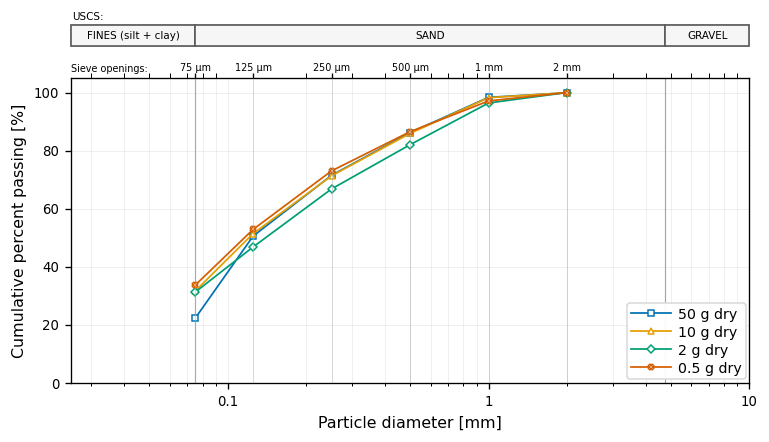

In [22]:
# ── Figure: Median per mass group (dry sieve) ────────────────────────────────
dry_groups = {
    "50 g dry" : ["50A", "50B"],
    "10 g dry" : ["10A", "10B"],
    "2 g dry"  : ["2A",  "2B"],
    "0.5 g dry": ["0.5A","0.5B"],
}

fig, ax = plot_sieve_group_medians(dry_groups, xlim=SIEVE_XLIM)
savefig(fig, "fig_3_6_dry_sieve_medians")
plt.show()


### 3.6 Wet-Prepared Sieving


Saved: figures/fig_3_7_wet_sieve_100_50_10.pdf; Word SVG: figures_word/svg/fig_3_7_wet_sieve_100_50_10.svg; Word PNG: figures_word/png_450dpi/fig_3_7_wet_sieve_100_50_10.png


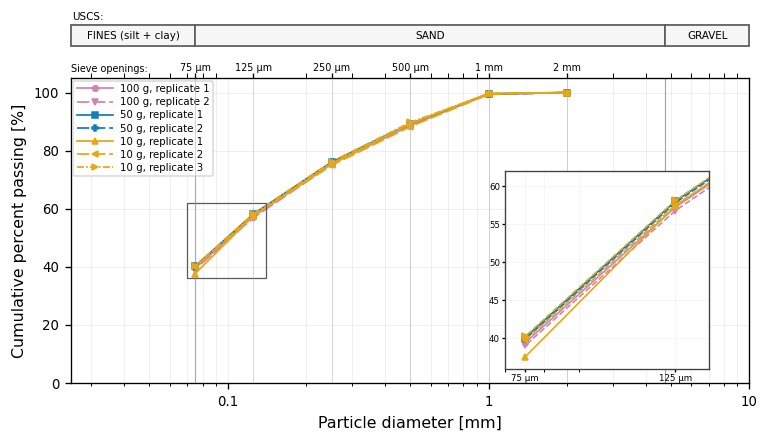

Saved: figures/fig_3_8_wet_sieve_2_05.pdf; Word SVG: figures_word/svg/fig_3_8_wet_sieve_2_05.svg; Word PNG: figures_word/png_450dpi/fig_3_8_wet_sieve_2_05.png


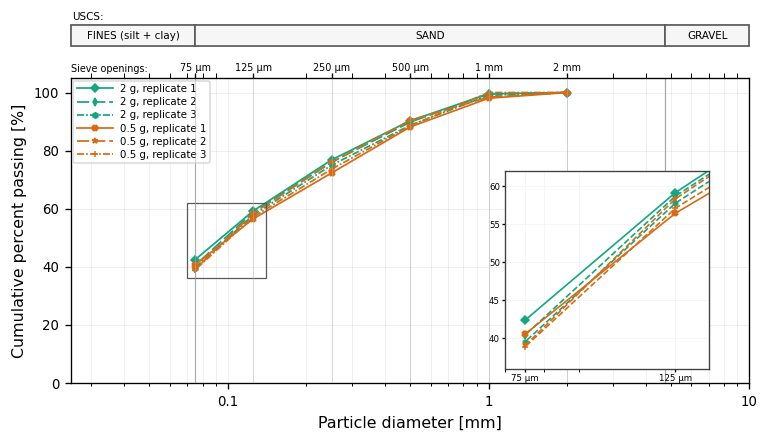

In [23]:
# ── Figures: All wet-sieve specimens ────────────────────────────────────────
WET_LARGE = ["100W1", "100W2", "50W1", "50W2", "10W1", "10W2", "10W3"]
WET_SMALL = ["2W1",   "2W2",   "2W3",  "0.5W1","0.5W2","0.5W3"]
WET_ALL   = WET_LARGE + WET_SMALL

fig, ax = plot_sieve(WET_LARGE, xlim=SIEVE_XLIM)
add_psd_zoom_inset(ax)
legend_clean(ax, fontsize=6.1, loc="upper left", handlelength=3.6, labelspacing=0.30, handletextpad=0.65, borderpad=0.34)
savefig(fig, "fig_3_7_wet_sieve_100_50_10")
plt.show()

fig, ax = plot_sieve(WET_SMALL, xlim=SIEVE_XLIM)
add_psd_zoom_inset(ax)
legend_clean(ax, fontsize=6.1, loc="upper left", handlelength=3.6, labelspacing=0.30, handletextpad=0.65, borderpad=0.34)
savefig(fig, "fig_3_8_wet_sieve_2_05")
plt.show()


Saved: figures/fig_3_9_wet_sieve_medians.pdf; Word SVG: figures_word/svg/fig_3_9_wet_sieve_medians.svg; Word PNG: figures_word/png_450dpi/fig_3_9_wet_sieve_medians.png


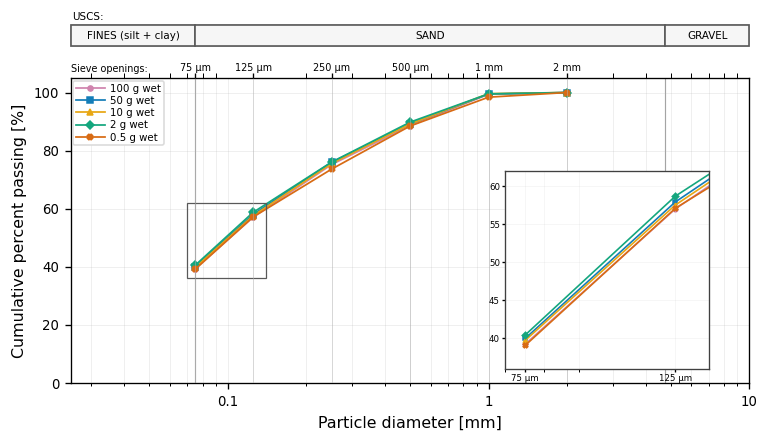

In [24]:
# ── Figure: Median per mass group (wet sieve) ────────────────────────────────
wet_groups = {
    "100 g wet": ["100W1","100W2"],
    "50 g wet" : ["50W1", "50W2"],
    "10 g wet" : ["10W1", "10W2","10W3"],
    "2 g wet"  : ["2W1",  "2W2", "2W3"],
    "0.5 g wet": ["0.5W1","0.5W2","0.5W3"],
}

fig, ax = plot_sieve_group_medians(wet_groups, band= None, xlim=SIEVE_XLIM)
add_psd_zoom_inset(ax)
legend_clean(ax, fontsize=6.1, loc="upper left", handlelength=2.8, labelspacing=0.22)
savefig(fig, "fig_3_9_wet_sieve_medians")
plt.show()


### 3.7 Bulk Hydrometer


Saved: figures/fig_3_10_hydro_bulk.pdf; Word SVG: figures_word/svg/fig_3_10_hydro_bulk.svg; Word PNG: figures_word/png_450dpi/fig_3_10_hydro_bulk.png


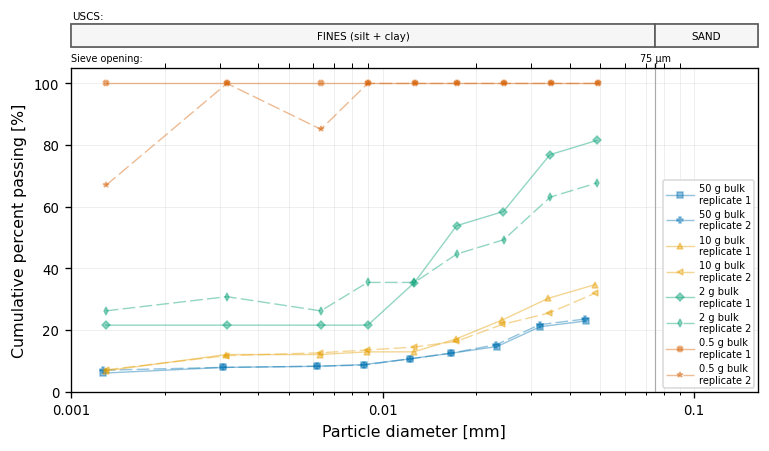

In [25]:
# ── Figure: All hydrometer specimens ────────────────────────────────────────
HYDRO_KEYS = ["50A", "50B", "10A", "10B", "2A", "2B", "0.5A", "0.5B"]
HYDRO_XLIM = (0.001, 0.16)
curves = []

for k in HYDRO_KEYS:
    d, p = hydro_curve(k)
    rep_idx = parse_rep_idx(k)
    bulk_ls = REPLICATE_LS.get(rep_idx, "-")
    curves.append({
        "label": specimen_label(k, "hydro_bulk"),
        "d_mm": d,
        "p": p,
        "style_key": k,
        "style": {**style_for(parse_mass(k), method="hydro_bulk", replicate_idx=rep_idx), "linestyle": bulk_ls, "alpha": 0.42, "linewidth": 0.85},
    })

fig, ax = plot_psd(
    curves,
    xlim=HYDRO_XLIM,
    show_overlay=False,
    show_mgs1=False,
    show_envelopes=False,
)
fig.set_size_inches(WORD_TEXT_WIDTH_IN, 3.85)
fig.subplots_adjust(top=0.84)
ax.set_xlim(*HYDRO_XLIM)
apply_fines_overlay(ax, xlim=HYDRO_XLIM)
for line in ax.get_lines():
    if "replicate 2" in (line.get_label() or ""):
        line.set_linestyle((0, (9, 3)))
legend_clean(ax, fontsize=5.9, loc="lower right",
             handlelength=2.8, labelspacing=0.42, borderpad=0.34,
             handletextpad=0.52, borderaxespad=0.35, ncol=1, numpoints=1)
savefig(fig, "fig_3_10_hydro_bulk", tight=False)
plt.show()


In [26]:
# ── Hydrometer QC table ──────────────────────────────────────────────────────
ref_hydro = ["50A", "50B"]
grid_qc   = np.logspace(np.log10(0.003), np.log10(0.05), 60)

ref_y = np.nanmean(np.vstack([
    interp_to_grid(*hydro_curve(k), grid_qc) for k in ref_hydro
]), axis=0)

qc_rows = []
for k in HYDRO_KEYS:
    df_h = HYDRO_WITH[k]
    y_k  = interp_to_grid(*hydro_curve(k), grid_qc)
    qc_rows.append({
        "Test ID"              : k,
        "Dry mass [g]"         : round(float(df_h["Md_g"].iloc[0]), 4),
        "Max (H – Lcorr)"      : round(float(df_h["signal"].max()), 2),
        "Low signal [%]"       : round(float(df_h["low_signal"].mean()) * 100, 1),
        "RMS vs 50g ref [pp]"  : round(float(np.sqrt(np.nanmean((y_k - ref_y)**2))), 2),
    })

print("Hydrometer QC table:")
display(pd.DataFrame(qc_rows).set_index("Test ID"))


Hydrometer QC table:


/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/2720558637.py:5: RuntimeWarning: Mean of empty slice
  ref_y = np.nanmean(np.vstack([


,Dry mass [g],Max (H – Lcorr),Low signal [%],RMS vs 50g ref [pp]
Test ID,,,,
50A,50.7665,12.44,0.0,0.19
50B,50.6476,12.77,0.0,0.19
10A,10.6262,3.94,0.0,5.48
10B,10.1510,3.47,0.0,4.45
2A,2.0286,1.77,44.4,32.56
2B,2.0267,1.47,0.0,28.94
0.5A,0.5074,0.87,0.0,87.83
0.5B,0.5142,0.77,22.2,84.93


### 3.8 Fines-Only Hydrometer Check


P(0.075 mm) scaling factor: 0.397 (39.7 %)
Fines-only runs computed: ['F0.5', 'F2', 'F10', 'F50']


,Fines mass [g],Bulk nominal [g],Bulk equiv. [g],Max signal (H-Lc),Low signal [%],Max raw fines [%],Max bulk-scaled [%],Pts >100 bulk-scaled
ID,,,,,,,,
F0.5,0.24,0.5,0.60,1.47,11.1,572.0,227.0,8
F2,0.94,2.0,2.37,3.27,0.0,325.1,129.0,3
F10,4.02,10.0,10.13,4.47,0.0,103.9,41.2,0
F50,21.56,50.0,54.34,16.27,0.0,70.6,28.0,0


Saved: figures/fig_3_11_hydro_bulk_vs_fines.pdf; Word SVG: figures_word/svg/fig_3_11_hydro_bulk_vs_fines.svg; Word PNG: figures_word/png_450dpi/fig_3_11_hydro_bulk_vs_fines.png


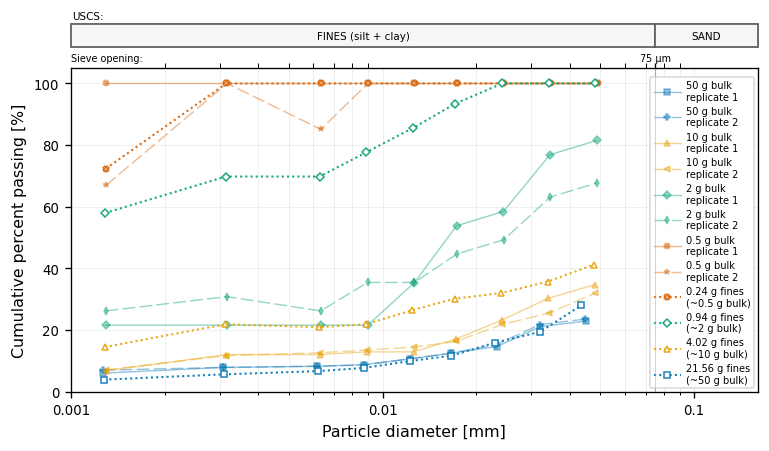

In [27]:
# Figure/Table input: fines-only hydrometer readings.
fines_raw = pd.read_csv(DATA_DIR / "hydrometer_fines_raw.csv")
FINES_HYDRO_RUNS = {
    test_id: {
        "fines_mass_g": float(sub["fines_mass_g"].iloc[0]),
        "bulk_nominal_g": float(sub["bulk_nominal_g"].iloc[0]),
        "data": list(sub[["t_min", "H", "T_C"]].itertuples(index=False, name=None)),
    }
    for test_id, sub in fines_raw.groupby("test_id", sort=False)
}

STYLE.update({
    "F0.5": style_for(0.5, method="hydro_fines", replicate_idx=0, marker="X", linestyle=(0,(1,1.5)), linewidth=1.25),
    "F2":   style_for(2,   method="hydro_fines", replicate_idx=0, marker="D", linestyle=(0,(1,1.5)), linewidth=1.25),
    "F10":  style_for(10,  method="hydro_fines", replicate_idx=0, marker="^", linestyle=(0,(1,1.5)), linewidth=1.25),
    "F50":  style_for(50,  method="hydro_fines", replicate_idx=0, marker="s", linestyle=(0,(1,1.5)), linewidth=1.25),
})

HYDRO_FINES = {}
for key, run in FINES_HYDRO_RUNS.items():
    fake = {"wet_mass_g": run["fines_mass_g"], "data": run["data"]}
    HYDRO_FINES[key] = compute_hydro_run(
        key, fake, wc_pct=0.0, rho_s=HYD_RHO_S, constants=HYDRO_CONST
    )

P075_SCALE = np.median([p075(k) for k in ["100W1", "100W2", "50W1", "50W2"]]) / 100.0

for key, df in HYDRO_FINES.items():
    p_raw = (
        HYDRO_CONST["coef_pct"]
        * (df["Gs_T"] / (df["Gs_T"] - 1.0))
        * (1000.0 / df["Md_g"])
        * (df["H"] - df["Lcorr"])
    )
    df["%finer_raw_rebuilt"] = p_raw
    df["%finer_bulk_raw"] = p_raw * P075_SCALE
    df["%finer_bulk"] = np.clip(df["%finer_bulk_raw"], 0, 100)
    df["over_100_bulk"] = df["%finer_bulk_raw"] > 100

print(f"P(0.075 mm) scaling factor: {P075_SCALE:.3f} ({P075_SCALE*100:.1f} %)")
print("Fines-only runs computed:", list(HYDRO_FINES.keys()))

rows = []
for key, run in FINES_HYDRO_RUNS.items():
    df = HYDRO_FINES[key]
    rows.append({
        "ID": key,
        "Fines mass [g]": run["fines_mass_g"],
        "Bulk nominal [g]": run["bulk_nominal_g"],
        "Bulk equiv. [g]": round(run["fines_mass_g"] / P075_SCALE, 2),
        "Max signal (H-Lc)": round(float(df["signal"].max()), 2),
        "Low signal [%]": round(float(df["low_signal"].mean()) * 100, 1),
        "Max raw fines [%]": round(float(df["%finer_raw_rebuilt"].max()), 1),
        "Max bulk-scaled [%]": round(float(df["%finer_bulk_raw"].max()), 1),
        "Pts >100 bulk-scaled": int(df["over_100_bulk"].sum()),
    })
display(pd.DataFrame(rows).set_index("ID"))

# Figure 3.11 - bulk hydrometer and fines-only hydrometer, bulk-equivalent basis.
HYDRO_XLIM = (0.001, 0.16)
bulk_keys = ["50A", "50B", "10A", "10B", "2A", "2B", "0.5A", "0.5B"]
curves = []

for k in bulk_keys:
    d, p = hydro_curve(k)
    rep_idx = parse_rep_idx(k)
    bulk_ls = REPLICATE_LS.get(rep_idx, "-")
    curves.append({
        "label": specimen_label(k, "hydro_bulk"),
        "d_mm": d,
        "p": p,
        "style_key": k,
        "style": {**style_for(parse_mass(k), method="hydro_bulk", replicate_idx=rep_idx), "linestyle": bulk_ls, "alpha": 0.42, "linewidth": 0.85},
    })

for k in FINES_HYDRO_RUNS:
    df = HYDRO_FINES[k].sort_values("D_mm")
    label = f"{FINES_HYDRO_RUNS[k]['fines_mass_g']:g} g fines\n(~{FINES_HYDRO_RUNS[k]['bulk_nominal_g']:g} g bulk)"
    curves.append({
        "label": label,
        "d_mm": df["D_mm"].to_numpy(float),
        "p": df["%finer_bulk"].to_numpy(float),
        "style_key": k,
        "style": {**STYLE.get(k, {}), "linestyle": (0,(1,1.5)), "linewidth": 1.25, "markersize": 3.2, "alpha": 0.95},
    })

fig, ax = plot_psd(
    curves,
    xlim=HYDRO_XLIM,
    show_overlay=False,
    show_mgs1=False,
    show_envelopes=False,
)
fig.set_size_inches(WORD_TEXT_WIDTH_IN, 3.85)
fig.subplots_adjust(top=0.84)
ax.set_xlim(*HYDRO_XLIM)
apply_fines_overlay(ax, xlim=HYDRO_XLIM)
for line in ax.get_lines():
    if "replicate 2" in (line.get_label() or ""):
        line.set_linestyle((0, (9, 3)))
legend_clean(ax, fontsize=5.9, loc="lower right",
             handlelength=2.8, labelspacing=0.42, borderpad=0.34,
             handletextpad=0.52, borderaxespad=0.35, ncol=1, numpoints=1)
savefig(fig, "fig_3_11_hydro_bulk_vs_fines", tight=False)
plt.show()


Saved: figures/fig_4_6_hydro_H_minus_Lcorr.pdf; Word SVG: figures_word/svg/fig_4_6_hydro_H_minus_Lcorr.svg; Word PNG: figures_word/png_450dpi/fig_4_6_hydro_H_minus_Lcorr.png


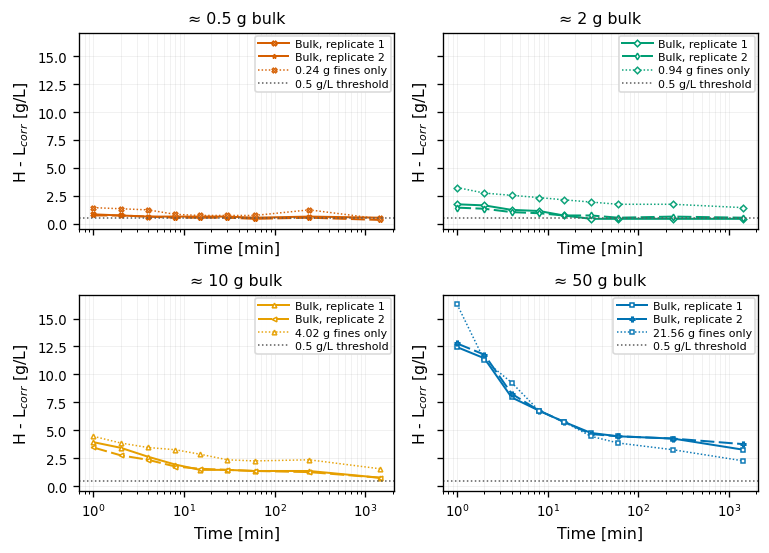

In [28]:
# ── Figure 4.6: Corrected hydrometer reading (H - Lcorr) over time ──────
# This is the corrected ASTM 152H reading used in the percent-finer calculation.
# The 0.5 g/L line is retained only as a practical low-reading threshold.

fig, axes = plt.subplots(2, 2,
                          figsize=(WORD_TEXT_WIDTH_IN, 4.7),
                          sharex=True, sharey=True)
axes = axes.flatten()

pair_map = [
    ("F0.5", ["0.5A","0.5B"]),
    ("F2",   ["2A",  "2B"]),
    ("F10",  ["10A", "10B"]),
    ("F50",  ["50A", "50B"]),
]

for ax, (fkey, bkeys) in zip(axes, pair_map):
    nom = FINES_HYDRO_RUNS[fkey]["bulk_nominal_g"]

    for bk in bkeys:
        df = HYDRO_WITH[bk]
        rep = parse_rep_idx(bk)
        ax.semilogx(df["t_min"], df["signal"], **{**STYLE.get(bk,{}),
                    "label": f"Bulk, replicate {rep+1}", "linewidth": 1.2,
                    "markersize": 2.8, "linestyle": REPLICATE_LS.get(rep, "-")})

    df_f = HYDRO_FINES[fkey]
    fm   = FINES_HYDRO_RUNS[fkey]["fines_mass_g"]
    ax.semilogx(df_f["t_min"], df_f["signal"], **{**STYLE.get(fkey,{}),
                "label": f"{fm:g} g fines only", "linewidth": 0.9,
                "markersize": 2.8, "linestyle": (0, (1, 1.4))})

    ax.axhline(0.5, color="0.35", ls=":", lw=0.9, label="0.5 g/L threshold")
    ax.set_title(f"≈ {nom:g} g bulk", fontsize=9.5)
    ax.set_ylabel("H - L$_{corr}$ [g/L]")
    ax.grid(True, which="both", alpha=0.35)
    legend_clean(ax, fontsize=6.6, handlelength=2.8, labelspacing=0.30)

for ax in axes:
    ax.set_xlabel("Time [min]")
plt.tight_layout()
savefig(fig, "fig_4_6_hydro_H_minus_Lcorr")
plt.show()


### 3.9 Stitched Full PSD


Median bulk-hydrometer curves are stitched to median wet-prepared sieve curves at 0.075 mm.


/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)
/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)
/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)
/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)


Saved: figures/fig_3_12_stitched_full.pdf; Word SVG: figures_word/svg/fig_3_12_stitched_full.svg; Word PNG: figures_word/png_450dpi/fig_3_12_stitched_full.png


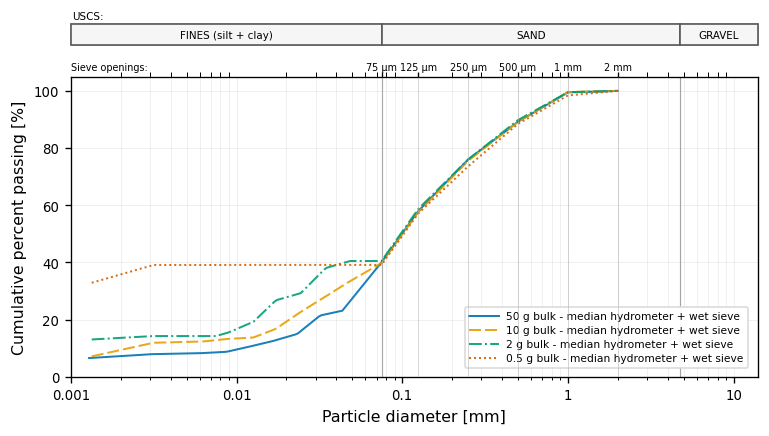

/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)
/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)
/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)
/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/3377264532.py:50: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(np.vstack(Ys), axis=0)


Saved: figures/fig_4_7_stitched_vs_reference.pdf; Word SVG: figures_word/svg/fig_4_7_stitched_vs_reference.svg; Word PNG: figures_word/png_450dpi/fig_4_7_stitched_vs_reference.png


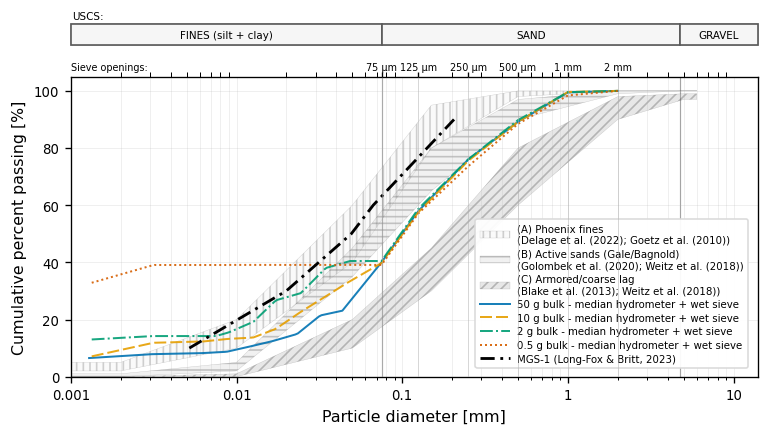

Gradation metrics - current stitched curves:


,Mass [g],P0.075 [%],D10 [mm],D30 [mm],D50 [mm],D60 [mm],D90 [mm],Cu,Cc,Use
0,50.0,40.02,0.0109,0.0544,0.0997,0.1354,0.5283,12.392,1.998,quantitative stitched PSD
1,10.0,39.76,0.0023,0.0390,0.1007,0.1375,0.5286,61.020,4.899,quantitative stitched PSD
2,2.0,40.47,NaN,0.0252,0.0980,0.1318,0.5078,NaN,NaN,scaled low-mass stitch; interpret cautiously
3,0.5,39.10,NaN,NaN,0.1022,0.1412,0.5571,NaN,NaN,scaled low-mass stitch; interpret cautiously


In [29]:
FULL_XLIM = PLOT_CFG["xlim_full"]

# Scenario E - two thesis figures, B&W readable.
#
# Figure 3.16: median hydrometer + wet sieve for 50, 10, 2, 0.5 g
#              without MGS-1 or Mars envelopes. The 50 g and 10 g curves use
#              the original quantitative stitch. The 2 g and 0.5 g curves are
#              diagnostic low-signal continuations, not quantitative PSDs.
# Figure 4.7: median hydrometer + wet sieve for 50 and 10 g
#              with MGS-1 line and Mars envelopes.

LINESTYLE_BY_MASS = {
    50:  "-",
    10:  (0, (6, 2)),
    2:   "-.",
    0.5: (0, (1, 1.5)),
}
MGS1_LINESTYLE = (0, (5, 2, 1, 2))
MGS1_LW = 1.7
MASS_LW = 1.20

HYDRO_GROUPS = {
    50 : ["50A",  "50B"],
    10 : ["10A",  "10B"],
    2  : ["2A",   "2B"],
    0.5: ["0.5A", "0.5B"],
}
WET_GROUPS = {
    100: ["100W1", "100W2"],
    50 : ["50W1",  "50W2"],
    10 : ["10W1",  "10W2", "10W3"],
    2  : ["2W1",   "2W2",  "2W3"],
    0.5: ["0.5W1", "0.5W2","0.5W3"],
}

def _median_sieve_curve(keys):
    """Median wet-sieve curve over replicate keys. Returns (d_mm, p_finer, p075_median)."""
    Ys, x_ref = [], None
    for k in keys:
        x, y, _ = sieve_curve(k)
        Ys.append(y)
        x_ref = x if x_ref is None else x_ref
    Y = np.vstack(Ys)
    return x_ref, np.nanmedian(Y, axis=0), float(np.nanmedian(Y[:, -1]))

def _median_bulk_hydro(keys):
    """Median bulk-hydrometer curve across replicate keys on a common diameter grid."""
    grid = np.logspace(np.log10(0.001), np.log10(0.075), 120)
    Ys = [interp_to_grid(*hydro_curve(k), grid) for k in keys]
    return grid, np.nanmedian(np.vstack(Ys), axis=0)

def _stitch_raw_quantitative(d_h, p_h, d_s, p_s, P075_val):
    """Original stitch used for 50 g and 10 g quantitative curves."""
    keep = d_h < PLOT_CFG["fines_end"]
    d_h2, p_h2 = d_h[keep], p_h[keep]
    y_s2 = p_s.copy()
    y_s2[-1] = P075_val
    d_all = np.concatenate([d_h2, [PLOT_CFG["fines_end"]], d_s])
    p_all = np.concatenate([p_h2, [P075_val], y_s2])
    df = pd.DataFrame({"d_mm": d_all, "p": p_all}).dropna()
    df = df.sort_values("d_mm").drop_duplicates("d_mm", keep="first")
    return df["d_mm"].to_numpy(float), df["p"].to_numpy(float)

def _stitch_low_mass_diagnostic(d_h, p_h, d_s, p_s, P075_val, mass):
    """Scaled low-mass stitch for signal-limited hydrometer curves.

    The hydrometer branch is treated as a fines-shape curve: its own 100 %
    level is mapped to the measured wet-sieve P(0.075 mm). The wet-sieve sand
    branch is then kept on its measured scale instead of being shifted upward.
    """
    keep = d_h < PLOT_CFG["fines_end"]
    d = np.asarray(d_h[keep], float)
    p = np.asarray(p_h[keep], float)
    m = np.isfinite(d) & np.isfinite(p) & (d > 0)
    d, p = d[m], p[m]
    order = np.argsort(d)
    d, p = d[order], p[order]
    p = np.maximum.accumulate(np.clip(p, 0, None))
    scale_ref = float(np.nanmax(p)) if p.size and np.isfinite(np.nanmax(p)) else 100.0
    scale_ref = max(scale_ref, 1e-9)
    p_scaled = np.clip(p / scale_ref * P075_val, 0, P075_val)

    d_s2 = np.asarray(d_s, dtype=float)
    y_s2 = np.asarray(p_s, dtype=float).copy()
    order_s = np.argsort(d_s2)
    d_s2, y_s2 = d_s2[order_s], y_s2[order_s]
    y_s2[np.argmin(np.abs(d_s2 - PLOT_CFG["fines_end"]))] = P075_val
    y_s2 = np.maximum.accumulate(y_s2)

    d_all = np.concatenate([d, [PLOT_CFG["fines_end"]], d_s2])
    p_all = np.concatenate([p_scaled, [P075_val], y_s2])
    df = pd.DataFrame({"d_mm": d_all, "p": p_all}).dropna()
    df = df.sort_values("d_mm").drop_duplicates("d_mm", keep="first")
    df["p"] = np.maximum.accumulate(df["p"].to_numpy(float))
    return df["d_mm"].to_numpy(float), df["p"].to_numpy(float)

def add_mgs1_line_only(ax,
                       d_um=(5.19, 19.96, 49.30, 66.85, 205.48),
                       p_pct=(10, 30, 50, 60, 90),
                       color="black", lw=MGS1_LW, ls=MGS1_LINESTYLE,
                       label="MGS-1 (Long-Fox & Britt, 2023)"):
    """Plot MGS-1 reference percentiles as a line, without markers."""
    d_mm = np.asarray(d_um, dtype=float) / 1000.0
    ax.plot(d_mm, p_pct, color=color, lw=lw, ls=ls, label=label, zorder=4)

def build_curve_for_mass(m):
    """Build one median stitched/diagnostic curve for a nominal mass level."""
    hydro_keys = HYDRO_GROUPS.get(m, [])
    wet_keys = WET_GROUPS.get(m, [])
    if not hydro_keys or not wet_keys:
        print(f"  -> missing hydrometer or wet-sieve data at {m} g; skipped")
        return None
    d_h, p_h = _median_bulk_hydro(hydro_keys)
    d_s, p_s, P075_med = _median_sieve_curve(wet_keys)
    if m in (50, 10):
        d_st, p_st = _stitch_raw_quantitative(d_h, p_h, d_s, p_s, P075_med)
    else:
        d_st, p_st = _stitch_low_mass_diagnostic(d_h, p_h, d_s, p_s, P075_med, m)
    label = f"{m} g bulk - median hydrometer + wet sieve"
    st = style_for(m, method="stitched", replicate_idx=0,
                   linestyle=LINESTYLE_BY_MASS.get(m, "--"), alpha=0.9)
    st.update(marker="None",
              linestyle=LINESTYLE_BY_MASS.get(m, "--"),
              linewidth=MASS_LW)
    return {"label": label, "d_mm": d_st, "p": p_st, "style": st,
            "mass": m, "P075": P075_med}

# Figure 3.12 - all stitched/diagnostic mass levels, no MGS-1, no envelopes.
masses_fig1 = [50, 10, 2, 0.5]
curves_fig1 = [c for c in (build_curve_for_mass(m) for m in masses_fig1)
               if c is not None]

fig1, ax1 = plot_psd(curves_fig1, xlim=FULL_XLIM, show_overlay=False, show_mgs1=False, show_envelopes=False)
fig1.set_size_inches(WORD_TEXT_WIDTH_IN, 3.85)
apply_psd_overlay(ax1)
legend_clean(ax1, fontsize=6.4, loc="lower right", bbox_to_anchor=(0.99, 0.02), handlelength=2.8, handletextpad=0.70, labelspacing=0.38, borderpad=0.42)
plt.tight_layout()
savefig(fig1, "fig_3_12_stitched_full")
plt.show()

# Figure 4.7 - stitched curves with MGS-1 line and Mars envelopes.
masses_fig2 = [50, 10, 2, 0.5]
curves_fig2 = [c for c in (build_curve_for_mass(m) for m in masses_fig2)
               if c is not None]

fig2, ax2 = plot_psd(curves_fig2, xlim=FULL_XLIM, show_overlay=False, show_mgs1=False, show_envelopes=True)
fig2.set_size_inches(WORD_TEXT_WIDTH_IN, 3.85)
apply_psd_overlay(ax2)
add_mgs1_line_only(ax2)
legend_clean(ax2, fontsize=6.1, loc="lower right", bbox_to_anchor=(0.99, 0.02), ncol=1, handlelength=3.0, labelspacing=0.36, borderpad=0.42, handletextpad=0.70)
plt.tight_layout()
savefig(fig2, "fig_4_7_stitched_vs_reference")
plt.show()

PERCENTILES = (10, 30, 50, 60, 90)

def _d_at_passing(d_mm, p_pct, target):
    """Diameter at a given percent passing, interpolated in log10(d).

    The stitched curves can contain plateaus, especially at the hydrometer-sieve
    join. For duplicate percent-passing values, keep the largest diameter on the
    plateau so D-values above P(0.075 mm) interpolate from the join point, not
    from an earlier hydrometer point with the same percent passing.
    """
    d = np.asarray(d_mm, dtype=float)
    p = np.asarray(p_pct, dtype=float)
    mask = np.isfinite(d) & np.isfinite(p) & (d > 0)
    d, p = d[mask], p[mask]
    if d.size < 2:
        return np.nan

    order = np.argsort(d)
    d = d[order]
    p = np.maximum.accumulate(p[order])

    df = pd.DataFrame({"d_mm": d, "p": p})
    df = df.groupby("p", as_index=False)["d_mm"].max().sort_values("p")
    p_s = df["p"].to_numpy(float)
    d_s = df["d_mm"].to_numpy(float)

    if target < p_s.min() or target > p_s.max():
        return np.nan
    log_d = np.interp(target, p_s, np.log10(d_s))
    return float(10 ** log_d)

def gradation_table(curves):
    """Gradation metrics for quantitative stitched curves.

    D-values are computed for the currently exported stitched curves. The low-mass
    2 g and 0.5 g curves remain interpretive because their hydrometer branch is
    scaled to the wet-sieve P(0.075 mm) join level.
    """
    rows = []
    for sc in curves:
        mass = sc["mass"]
        quantitative = mass in (50, 10)
        d_mm, p_pct = sc["d_mm"], sc["p"]
        Ds = {f"D{q}_mm": _d_at_passing(d_mm, p_pct, q) for q in PERCENTILES}
        D10, D30, D60 = Ds["D10_mm"], Ds["D30_mm"], Ds["D60_mm"]
        Cu = D60 / D10 if (np.isfinite(D60) and np.isfinite(D10) and D10 > 0) else np.nan
        Cc = (D30**2) / (D10 * D60) if all(np.isfinite([D10, D30, D60])) and D10 > 0 and D60 > 0 else np.nan
        rows.append({
            "Mass [g]": mass,
            "P0.075 [%]": round(sc["P075"], 2),
            "D10 [mm]": round(Ds["D10_mm"], 4) if np.isfinite(Ds["D10_mm"]) else np.nan,
            "D30 [mm]": round(Ds["D30_mm"], 4) if np.isfinite(Ds["D30_mm"]) else np.nan,
            "D50 [mm]": round(Ds["D50_mm"], 4) if np.isfinite(Ds["D50_mm"]) else np.nan,
            "D60 [mm]": round(Ds["D60_mm"], 4) if np.isfinite(Ds["D60_mm"]) else np.nan,
            "D90 [mm]": round(Ds["D90_mm"], 4) if np.isfinite(Ds["D90_mm"]) else np.nan,
            "Cu": round(Cu, 3) if np.isfinite(Cu) else np.nan,
            "Cc": round(Cc, 3) if np.isfinite(Cc) else np.nan,
            "Use": "quantitative stitched PSD" if quantitative else "scaled low-mass stitch; interpret cautiously",
        })
    return pd.DataFrame(rows).sort_values("Mass [g]", ascending=False).reset_index(drop=True)

df_grad = gradation_table(curves_fig1)
print("Gradation metrics - current stitched curves:")
display(df_grad)
Path("tables").mkdir(exist_ok=True)
df_grad.to_csv("tables/table_3_7_gradation_stitched.csv", index=False)


Figure 4.7 is generated together with Figure 3.12 in the previous cell.


### 3.10 Sieve Metrics: P(0.075 mm) and D50


In [30]:
# ── Helper: parse specimen mass from test ID ─────────────────────────────────
def parse_specimen_mass(key):
    """Extract nominal specimen mass [g] from a test ID string."""
    s = str(key).replace(",", ".")
    m = re.match(r"^(\d+(?:\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan

def group_stat(keys, val_fn, stat="median"):
    """Compute per-mass statistics for a list of keys."""
    by_mass = {}
    for k in keys:
        v = val_fn(k)
        by_mass.setdefault(parse_specimen_mass(k), []).append(v)
    masses = sorted(by_mass)
    center = [np.median(by_mass[m]) if stat == "median" else np.mean(by_mass[m])
              for m in masses]
    sd = [np.std(by_mass[m]) for m in masses]
    return masses, center, sd, by_mass


Saved: figures/fig_4_4_alt_p075_dry_vs_wet_points.pdf; Word SVG: figures_word/svg/fig_4_4_alt_p075_dry_vs_wet_points.svg; Word PNG: figures_word/png_450dpi/fig_4_4_alt_p075_dry_vs_wet_points.png


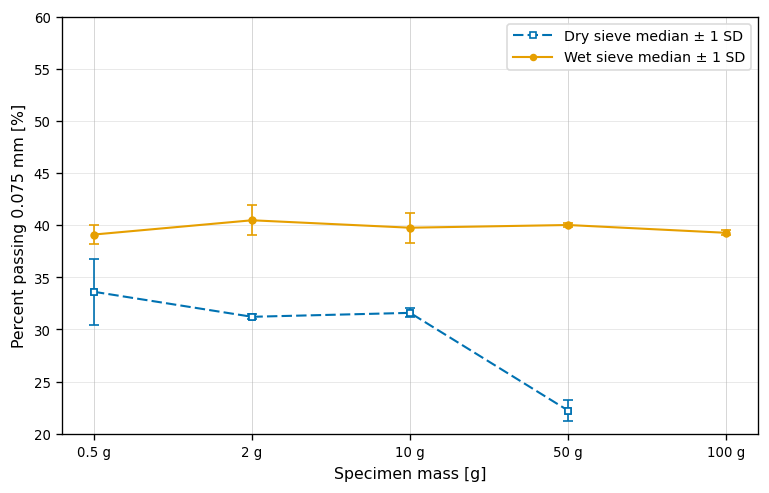

In [31]:
# Figure 4.4 - point/line version with median ± 1 SD.
MASS_PAIRS = [
    # (mass_g,  dry_keys,              wet_keys)
    (0.5,  ["0.5A", "0.5B"],      ["0.5W1","0.5W2","0.5W3"]),
    (2,    ["2A",   "2B"],        ["2W1",  "2W2",  "2W3"]),
    (10,   ["10A",  "10B"],       ["10W1", "10W2", "10W3"]),
    (50,   ["50A",  "50B"],       ["50W1", "50W2"]),
    (100,  None,                  ["100W1","100W2"]),
]

fig_alt, ax_alt = plt.subplots()
xs = np.arange(len(MASS_PAIRS), dtype=float)
dry_med, wet_med = [], []
dry_sd, wet_sd = [], []
for mass, dry_k, wet_k in MASS_PAIRS:
    if dry_k:
        vals = np.array([p075(k) for k in dry_k], float)
        med = np.nanmedian(vals)
        dry_med.append(med); dry_sd.append(np.nanstd(vals, ddof=1) if len(vals) > 1 else 0.0)
    else:
        dry_med.append(np.nan); dry_sd.append(np.nan)
    if wet_k:
        vals = np.array([p075(k) for k in wet_k], float)
        med = np.nanmedian(vals)
        wet_med.append(med); wet_sd.append(np.nanstd(vals, ddof=1) if len(vals) > 1 else 0.0)
    else:
        wet_med.append(np.nan); wet_sd.append(np.nan)

dry_med = np.array(dry_med, float); wet_med = np.array(wet_med, float)
dry_sd = np.array(dry_sd, float); wet_sd = np.array(wet_sd, float)
for i, med in enumerate(dry_med):
    if np.isfinite(med):
        ax_alt.errorbar(xs[i], med, yerr=dry_sd[i], fmt="s",
                        color="#0072B2", markerfacecolor="white", markeredgecolor="#0072B2",
                        ms=4.0, capsize=3, lw=1.0, zorder=4)
for i, med in enumerate(wet_med):
    if np.isfinite(med):
        ax_alt.errorbar(xs[i], med, yerr=wet_sd[i], fmt="o",
                        color="#E69F00", markerfacecolor="#E69F00", markeredgecolor="#E69F00",
                        ms=4.0, capsize=3, lw=1.0, zorder=4)
mask_d = np.isfinite(dry_med); mask_w = np.isfinite(wet_med)
ax_alt.plot(xs[mask_d], dry_med[mask_d], color="#0072B2", marker="s", markerfacecolor="white", markeredgecolor="#0072B2", ls=(0,(5,2)), lw=1.25, label="Dry sieve median ± 1 SD")
ax_alt.plot(xs[mask_w], wet_med[mask_w], color="#E69F00", marker="o", markerfacecolor="#E69F00", markeredgecolor="#E69F00", ls="-", lw=1.25, label="Wet sieve median ± 1 SD")
ax_alt.set_xticks(xs)
ax_alt.set_xticklabels([f"{m:g} g" for m, *_ in MASS_PAIRS])
ax_alt.set_ylabel("Percent passing 0.075 mm [%]")
ax_alt.set_xlabel("Specimen mass [g]")
ax_alt.set_ylim(20, 60)
ax_alt.grid(axis="y", lw=0.35, alpha=0.45)
ax_alt.legend(frameon=True, facecolor="white", framealpha=0.94, edgecolor="0.85", loc="best", handlelength=2.8)
plt.tight_layout()
savefig(fig_alt, "fig_4_4_alt_p075_dry_vs_wet_points")
plt.show()


Saved: figures/fig_4_5_D50_vs_mass.pdf; Word SVG: figures_word/svg/fig_4_5_D50_vs_mass.svg; Word PNG: figures_word/png_450dpi/fig_4_5_D50_vs_mass.png


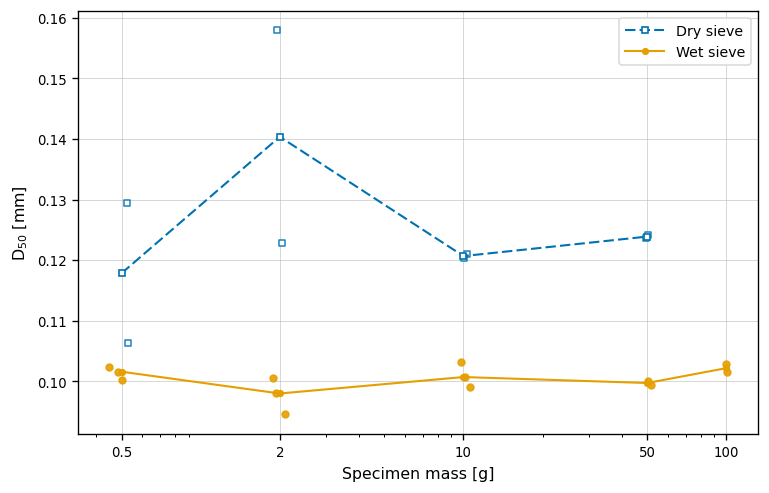

In [32]:
DRY_KEYS = ["50A", "50B", "10A", "10B", "2A", "2B", "0.5A", "0.5B"]
WET_LARGE = ["100W1", "100W2", "50W1", "50W2", "10W1", "10W2", "10W3"]
WET_SMALL = ["2W1", "2W2", "2W3", "0.5W1", "0.5W2", "0.5W3"]
WET_ALL = WET_LARGE + WET_SMALL

# ── Figure: D50 vs. specimen mass ────────────────────────────────────────────
fig, ax = plt.subplots()

def plot_d50_scatter(keys, label, marker, color):
    xs_all, ys_all = [], []
    for k in keys:
        d, p, _ = sieve_curve(k)
        d50 = D_at_pct(d, p, 50)
        xs_all.append(parse_specimen_mass(k))
        ys_all.append(d50)
    xs_all = np.array(xs_all, float)
    ys_all = np.array(ys_all, float)

    rng    = np.random.default_rng(0)
    xs_jit = 10 ** (np.log10(xs_all) + rng.normal(0, 0.02, len(xs_all)))
    ax.scatter(xs_jit, ys_all, marker=marker, facecolor="white" if label.startswith("Dry") else color, edgecolor=color, linewidth=0.9, s=17, alpha=0.9, zorder=3)

    by_mass = {}
    for x_, y_ in zip(xs_all, ys_all):
        by_mass.setdefault(x_, []).append(y_)
    masses_s = sorted(by_mass)
    medians  = [np.median(by_mass[m]) for m in masses_s]
    ax.plot(masses_s, medians, marker=marker, color=color, lw=1.25, ms=3.3,
            markerfacecolor="white" if label.startswith("Dry") else color, markeredgecolor=color,
            linestyle=(0,(5,2)) if label.startswith("Dry") else "-", label=label, zorder=4)

plot_d50_scatter(DRY_KEYS, "Dry sieve",  "s", "#0072B2")
plot_d50_scatter(WET_ALL,  "Wet sieve",  "o", "#E69F00")

ax.set_xscale("log")
unique_masses = sorted({parse_specimen_mass(k) for k in DRY_KEYS + WET_ALL})
ax.set_xticks(unique_masses)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Specimen mass [g]")
ax.set_ylabel("D$_{50}$ [mm]")
ax.legend(frameon=True, facecolor="white", framealpha=0.92, edgecolor="0.85", handlelength=2.8)
plt.tight_layout()
savefig(fig, "fig_4_5_D50_vs_mass")
plt.show()


### 3.11 Mars Reference PSD Background


Saved: figures/figure_2_1_mars_reference_psd.pdf; Word SVG: figures_word/svg/figure_2_1_mars_reference_psd.svg; Word PNG: figures_word/png_450dpi/figure_2_1_mars_reference_psd.png


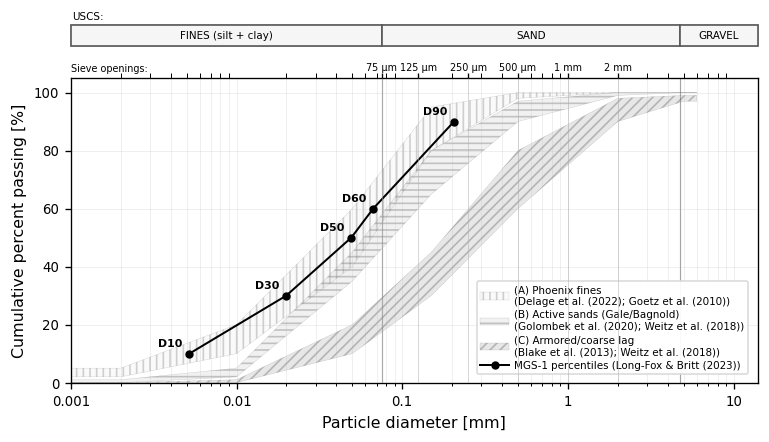

In [33]:
# ── Reference background PSD plot (Section 3.10) ───────────────────────────
# Identical structure to plot_reference_band (Section 3.8):
#   same figsize, setup_psd_ax, apply_psd_overlay, legend style.
# Difference: no min–max band, no median line; full envelope legend labels.

def plot_mars_reference(xlim=None, ylim=None,
                        show_overlay=None, show_mgs1=None):
    cfg  = PLOT_CFG
    xlim = xlim or cfg["xlim_full"]
    ylim = ylim or cfg["ylim"]
    show_overlay = cfg["show_overlay"] if show_overlay is None else show_overlay
    show_mgs1    = True               if show_mgs1    is None else show_mgs1

    fig, ax = plt.subplots(figsize=cfg.get("figsize", plt.rcParams["figure.figsize"]))

    # Envelopes with full reference labels (only difference from a plain plot)
    add_mars_envelopes(ax, show=True, full_labels=True)

    # Standard axis setup — same as every other PSD plot
    setup_psd_ax(ax, xlim=xlim, ylim=ylim,
                 xlabel="Particle diameter [mm]",
                 ylabel="Cumulative percent passing [%]")

    # MGS-1 line + annotated markers
    add_mgs1(ax, show=show_mgs1)
    ax.set_xticks([0.001, 0.01, 0.1, 1, 10])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    # Overlay (USCS header + sieve ticks) — same helper, same position
    if show_overlay:
        apply_psd_overlay(ax)

    legend_clean(ax, fontsize=6.2, loc="lower right", bbox_to_anchor=(0.99, 0.02), ncol=1, handlelength=2.8, labelspacing=0.34, borderpad=0.36, handletextpad=0.48)
    plt.tight_layout()
    return fig, ax

fig_ref, ax_ref = plot_mars_reference()
savefig(fig_ref, "figure_2_1_mars_reference_psd")
plt.show()


### 3.12 Dry vs Wet Median Sieve Curves


Saved: figures/fig_4_3_dry_vs_wet_medians.pdf; Word SVG: figures_word/svg/fig_4_3_dry_vs_wet_medians.svg; Word PNG: figures_word/png_450dpi/fig_4_3_dry_vs_wet_medians.png


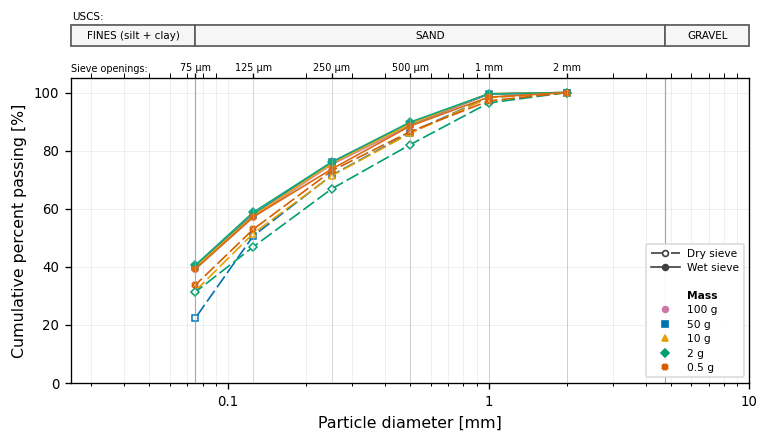

In [34]:
# Figure 4.3 - Median dry and wet-prepared sieve curves.
ALL_GROUPS = {
    "50 g dry sieve" : ["50A",  "50B"],
    "10 g dry sieve" : ["10A",  "10B"],
    "2 g dry sieve"  : ["2A",   "2B"],
    "0.5 g dry sieve": ["0.5A", "0.5B"],
    "100 g wet sieve": ["100W1","100W2"],
    "50 g wet sieve" : ["50W1", "50W2"],
    "10 g wet sieve" : ["10W1", "10W2","10W3"],
    "2 g wet sieve"  : ["2W1",  "2W2", "2W3"],
    "0.5 g wet sieve": ["0.5W1","0.5W2","0.5W3"],
}

fig, ax = plot_sieve_group_medians(ALL_GROUPS, band=None, xlim=SIEVE_XLIM)

for line in ax.get_lines():
    label = (line.get_label() or "").lower()
    if "dry" in label:
        line.set_linestyle((0, (8, 2.5)))
        line.set_markerfacecolor("white")
        line.set_linewidth(1.00)
    elif "wet" in label:
        line.set_linestyle("-")
        line.set_markerfacecolor(line.get_color())
        line.set_linewidth(1.00)

legend_handles = [
    Line2D([0], [0], color="0.25", marker="o", markerfacecolor="white", markeredgecolor="0.25",
           linestyle=(0, (9, 3)), lw=1.0, label="Dry sieve"),
    Line2D([0], [0], color="0.25", marker="o", markerfacecolor="0.25", markeredgecolor="0.25",
           linestyle="-", lw=1.0, label="Wet sieve"),
    Line2D([], [], color="none", linestyle="none", label=" "),
    Line2D([], [], color="none", linestyle="none", label="Mass"),
]
legend_handles += [Line2D([0], [0], color=mass_color(m), marker=mass_marker(m),
                          markerfacecolor=mass_color(m), markeredgecolor=mass_color(m),
                          linestyle="none", lw=0, label=f"{m:g} g")
                   for m in [100, 50, 10, 2, 0.5]]
leg = ax.legend(handles=legend_handles, loc="lower right", frameon=True, facecolor="white",
                framealpha=0.94, edgecolor="0.85", fontsize=6.4, ncol=1,
                handlelength=2.8, handletextpad=0.65, columnspacing=0.85,
                labelspacing=0.42, borderpad=0.42)
for txt in leg.get_texts():
    if txt.get_text() == " ":
        txt.set_fontsize(2)
    if txt.get_text() == "Mass":
        txt.set_fontweight("bold")
savefig(fig, "fig_4_3_dry_vs_wet_medians")
plt.show()


### 3.13 PSD Method Sensitivity


/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/2640490829.py:11: RuntimeWarning: Mean of empty slice
  y_ref_bulk_h = np.nanmean(


Saved: figures/fig_4_2_rms_method_sensitivity.pdf; Word SVG: figures_word/svg/fig_4_2_rms_method_sensitivity.svg; Word PNG: figures_word/png_450dpi/fig_4_2_rms_method_sensitivity.png


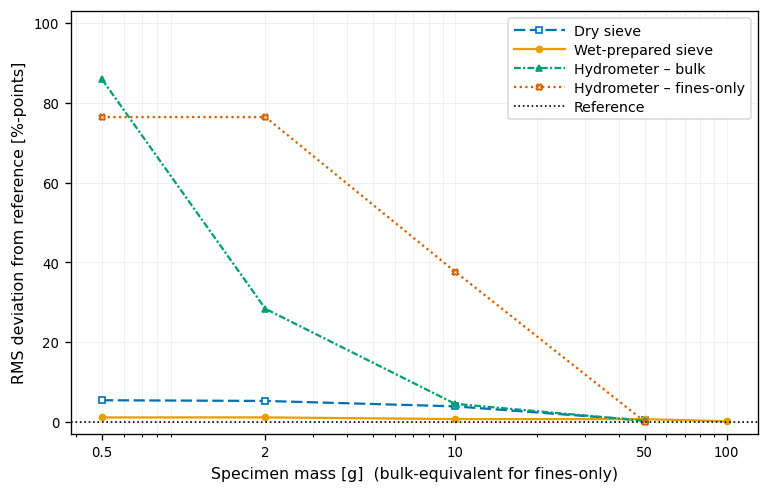

RMS summary (%-points):
  Mass [g]      Dry      Wet   Bulk H   Fines H
       0.5     5.38     1.07    85.88     76.43
         2     5.21     1.08    28.32     76.43
        10     3.85     0.66     4.47     37.63
        50     0.32     0.64     0.21      0.00
       100        —     0.13        —         —


In [35]:
# ── Figure: RMS deviation from reference – method sensitivity summary ─────────
hydro_grid = np.logspace(np.log10(0.001), np.log10(0.07), 80)

# ── Reference curves ─────────────────────────────────────────────────────────
y_ref_dry = np.median(
    np.vstack([sieve_curve(k)[1] for k in ["50A","50B"]]), axis=0)

y_ref_wet = np.median(
    np.vstack([sieve_curve(k)[1] for k in ["100W1","100W2"]]), axis=0)

y_ref_bulk_h = np.nanmean(
    np.vstack([interp_to_grid(*hydro_curve(k), hydro_grid) for k in ["50A","50B"]]),
    axis=0)

y_ref_fines_h = interp_to_grid(*hydro_curve("F50", src=HYDRO_FINES), hydro_grid)

# ── RMS helper functions ──────────────────────────────────────────────────────
def rms_sieve(keys, ref):
    vals = []
    for k in keys:
        _, y, _ = sieve_curve(k)
        vals.append(np.sqrt(np.mean((y - ref)**2)))
    return float(np.mean(vals))

def rms_hydro(keys, ref, grid, src=None):
    src = HYDRO_WITH if src is None else src
    vals = []
    for k in keys:
        y = interp_to_grid(*hydro_curve(k, src=src), grid)
        diff = y - ref
        m    = np.isfinite(diff)
        if m.sum() > 5:
            vals.append(np.sqrt(np.nanmean(diff[m]**2)))
    return float(np.mean(vals)) if vals else np.nan

# ── Groups and RMS per mass ───────────────────────────────────────────────────
dry_grps   = {0.5:["0.5A","0.5B"], 2:["2A","2B"],
              10:["10A","10B"],     50:["50A","50B"]}

wet_grps   = {0.5:["0.5W1","0.5W2","0.5W3"], 2:["2W1","2W2","2W3"],
              10:["10W1","10W2","10W3"],       50:["50W1","50W2"],
              100:["100W1","100W2"]}

bulk_h_grps= {0.5:["0.5A","0.5B"], 2:["2A","2B"],
              10:["10A","10B"],     50:["50A","50B"]}

fines_h_grps = {
    0.5 : ["F0.5"],   # bulk-equivalent mass on x-axis
    2   : ["F2"],
    10  : ["F10"],
    50  : ["F50"],
}

m_dry   = sorted(dry_grps)
m_wet   = sorted(wet_grps)
m_bh    = sorted(bulk_h_grps)
m_fh    = sorted(fines_h_grps)

rms_dry  = [rms_sieve(dry_grps[m],       y_ref_dry)    for m in m_dry]
rms_wet  = [rms_sieve(wet_grps[m],       y_ref_wet)    for m in m_wet]
rms_bh   = [rms_hydro(bulk_h_grps[m],   y_ref_bulk_h,  hydro_grid)              for m in m_bh]
rms_fh   = [rms_hydro(fines_h_grps[m],  y_ref_fines_h, hydro_grid,
                       src=HYDRO_FINES)  for m in m_fh]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots()

ax.plot(m_dry, rms_dry, marker="s", linestyle=(0,(5,2)), lw=1.35, ms=3.6, color="#0072B2",
        markerfacecolor="white", markeredgecolor="#0072B2", label="Dry sieve")
ax.plot(m_wet, rms_wet, marker="o", linestyle="-", lw=1.35, ms=3.6, color="#E69F00",
        markerfacecolor="#E69F00", markeredgecolor="#E69F00", label="Wet-prepared sieve")
ax.plot(m_bh,  rms_bh, marker="^", linestyle=(0,(3,1,1,1)), lw=1.35, ms=3.6, color="#009E73",
        markerfacecolor="#009E73", markeredgecolor="#009E73", label="Hydrometer – bulk")
ax.plot(m_fh,  rms_fh, marker="X", linestyle=(0,(1,1.5)), lw=1.35, ms=3.6, color="#D55E00",
        markerfacecolor="white", markeredgecolor="#D55E00", label="Hydrometer – fines-only")
plt.axhline(y=0, color='black', linestyle=':', linewidth=1, label="Reference")

ax.set_xscale("log")
all_masses = sorted(set(m_dry + m_wet + m_bh + m_fh))
ax.set_xticks(all_masses)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Specimen mass [g]  (bulk-equivalent for fines-only)")
ax.set_ylabel("RMS deviation from reference [%-points]")
ax.set_ylim(-3, 103)
ax.legend(frameon=True, facecolor="white", framealpha=0.92, edgecolor="0.85", handlelength=3.6, handletextpad=0.65, labelspacing=0.35)
ax.grid(True, which="both", alpha=0.35)
plt.tight_layout()
savefig(fig, "fig_4_2_rms_method_sensitivity")
plt.show()

# Print summary table
print("RMS summary (%-points):")
print(f"{'Mass [g]':>10} {'Dry':>8} {'Wet':>8} {'Bulk H':>8} {'Fines H':>9}")
for m in all_masses:
    d = f"{dry_grps.get(m) and rms_dry[m_dry.index(m)]:.2f}" if m in m_dry else "—"
    w = f"{rms_wet[m_wet.index(m)]:.2f}" if m in m_wet else "—"
    b = f"{rms_bh[m_bh.index(m)]:.2f}"   if m in m_bh  else "—"
    f_ = f"{rms_fh[m_fh.index(m)]:.2f}"  if m in m_fh  else "—"
    print(f"{m:>10g} {d:>8} {w:>8} {b:>8} {f_:>9}")


---
## 4. Loose and Tapped Bulk Density


### 4.1 Input Data


In [36]:
YLIM_RHO = (1, 2)
YLIM_DELTA = None

loose_raw = pd.read_csv(DATA_DIR / "loose_tapped_raw.csv")
REPLICATES = {}
value_cols = ["mass_loose_g", "V_loose_mL", "mass_tap_g", "V_tap_500", "V_tap_750", "V_tap_1250"]
for replicate, sub in loose_raw.groupby("replicate", sort=False):
    first = sub.iloc[0]
    rep = {
        "nominal_g": float(first["nominal_g"]),
        "V_cyl_mL": float(first["V_cyl_mL"]),
        "D_cyl_mm": float(first["D_cyl_mm"]),
        "m_cyl_g": float(first["m_cyl_g"]),
        "note": str(replicate),
    }
    for col in value_cols:
        rep[col] = sub[col].dropna().astype(float).tolist()
    REPLICATES[replicate] = rep

print(f"Loaded loose/tapped replicates: {len(REPLICATES)}")


Loaded loose/tapped replicates: 8


### 4.2 Calculations and Summary Statistics


In [37]:
# ── Calculations per replicate (loose + tapped) ──────────────────────────────
def nan_mean(seq):
    arr = np.array(seq, dtype=float)
    return np.nanmean(arr) if np.any(np.isfinite(arr)) else np.nan

def nan_std(seq, ddof=1):
    arr = np.array(seq, dtype=float)
    if np.isfinite(arr).sum() < 2:
        return np.nan
    return np.nanstd(arr, ddof=ddof)

def replicate_metrics(rep):
    mc = rep["m_cyl_g"]
    m_loose_net = np.array(rep["mass_loose_g"], float) - mc
    V_loose     = np.array(rep["V_loose_mL"],   float)
    m_tap_net   = np.array(rep["mass_tap_g"],   float) - mc
    V500  = np.array(rep["V_tap_500"],  float)
    V750  = np.array(rep["V_tap_750"],  float)
    V1250 = np.array(rep["V_tap_1250"], float)

    with np.errstate(divide="ignore", invalid="ignore"):
        rho_loose_i = m_loose_net / V_loose

    mbar = nan_mean(m_loose_net)
    Vbar = nan_mean(V_loose)
    rho_loose = mbar / Vbar if np.isfinite(mbar) and np.isfinite(Vbar) and Vbar > 0 else np.nan

    V500m, V750m, V1250m = nan_mean(V500), nan_mean(V750), nan_mean(V1250)
    V_tap_stable = np.nanmin([V500m, V750m, V1250m])
    stabilized = (abs(V1250m - V750m) / V750m < 0.02) if (np.isfinite(V750m) and V750m > 0) else False

    mbar_t = nan_mean(m_tap_net)
    rho_tap = mbar_t / V_tap_stable if np.isfinite(mbar_t) and np.isfinite(V_tap_stable) and V_tap_stable > 0 else np.nan

    rho_500  = mbar_t / V500m  if np.isfinite(V500m)  and V500m  > 0 else np.nan
    rho_750  = mbar_t / V750m  if np.isfinite(V750m)  and V750m  > 0 else np.nan
    rho_1250 = mbar_t / V1250m if np.isfinite(V1250m) and V1250m > 0 else np.nan

    HR = rho_tap / rho_loose if np.isfinite(rho_tap) and np.isfinite(rho_loose) and rho_loose > 0 else np.nan
    CI = (rho_tap - rho_loose) / rho_tap * 100 if np.isfinite(HR) else np.nan

    return dict(
        nominal_g = rep["nominal_g"], V_cyl_mL = rep["V_cyl_mL"],
        D_cyl_mm = rep["D_cyl_mm"], note = rep["note"],
        n_loose = int(np.isfinite(V_loose).sum()),
        m_loose_mean = mbar, m_loose_sd = nan_std(m_loose_net),
        V_loose_mean = Vbar, V_loose_sd = nan_std(V_loose),
        rho_loose = rho_loose,
        rho_loose_cv = (np.nanstd(rho_loose_i, ddof=1)/np.nanmean(rho_loose_i)*100
                        if np.isfinite(rho_loose_i).sum() > 1 else np.nan),
        gamma_d_min = rho_loose * G if np.isfinite(rho_loose) else np.nan,
        m_tap_mean = mbar_t,
        V_tap_500_mean = V500m, V_tap_750_mean = V750m, V_tap_1250_mean = V1250m,
        V_tap_stable = V_tap_stable, stabilized = stabilized,
        rho_tap_500 = rho_500, rho_tap_750 = rho_750, rho_tap_1250 = rho_1250,
        rho_tap = rho_tap,
        gamma_d_max = rho_tap * G if np.isfinite(rho_tap) else np.nan,
        HR = HR, CI = CI,
    )

records = {rid: replicate_metrics(r) for rid, r in REPLICATES.items()}
df_lt = pd.DataFrame(records).T
df_lt.index.name = "replicate"
df_lt.reset_index(inplace=True)

# ── NEW: Void ratio calculations (after supervisor comment) ──────────────────
# e = rho_s / rho_d - 1
# Uses particle density from pyknometer Section 2 (ref_rho_pyk) by default.
try:
    RHO_S_LT = float(ref_rho_pyk)
    print(f"Using rho_s from Section 2 pyknometer: {RHO_S_LT:.4f} g/cm³")
except NameError:
    RHO_S_LT = 2.987  # fallback to the value used in Section 3 hydrometer
    print(f"ref_rho_pyk not available, using fallback rho_s = {RHO_S_LT} g/cm³")

for c_in, c_out in [("rho_loose", "e_max"), ("rho_tap", "e_min")]:
    df_lt[c_out] = RHO_S_LT / pd.to_numeric(df_lt[c_in], errors="coerce") - 1.0

print(f"\nVoid ratio columns added: e_max (loose), e_min (tapped).")
df_lt[["replicate","nominal_g","V_cyl_mL","rho_loose","rho_tap","e_max","e_min"]].round(3)


Using rho_s from Section 2 pyknometer: 2.9878 g/cm³

Void ratio columns added: e_max (loose), e_min (tapped).


,replicate,nominal_g,V_cyl_mL,rho_loose,rho_tap,e_max,e_min
0,R55_1,55.0,100.0,1.255984,1.445709,1.379,1.067
1,R55_2,55.0,100.0,1.236429,1.418888,1.416,1.106
2,R10_2_25mL,10.0,25.0,1.230762,1.434986,1.428,1.082
3,R10_3_25mL,10.0,25.0,1.224384,1.445425,1.440,1.067
4,R10_1_10mL,10.0,10.0,1.23739,1.422836,1.415,1.100
5,R2_1,2.0,10.0,1.18592,1.616031,1.519,0.849
6,R2_2,2.0,10.0,1.190769,1.515049,1.509,0.972
7,R2_3,2.0,10.0,1.150665,1.504215,1.597,0.986


### 4.3 Tables


#### Table 1: Full Replicate Table


In [38]:
# ── Table 1: Full replicate table ────────────────────────────────────────────
cols_t1 = [
    "replicate", "nominal_g", "V_cyl_mL", "D_cyl_mm", "n_loose",
    "rho_loose", "rho_tap", "gamma_d_min", "gamma_d_max",
    "e_max", "e_min",
    "HR", "CI", "rho_loose_cv", "stabilized", "note",
]
table1 = df_lt[cols_t1].copy()
num_cols = ["rho_loose","rho_tap","gamma_d_min","gamma_d_max",
            "e_max","e_min","HR","CI","rho_loose_cv"]
for c in num_cols:
    table1[c] = pd.to_numeric(table1[c], errors="coerce").round(3)
table1.rename(columns={
    "nominal_g": "Nominal mass [g]",
    "V_cyl_mL" : "V_cyl [mL]",
    "D_cyl_mm" : "D_cyl [mm]",
    "rho_loose": "ρ_loose [g/cm³]",
    "rho_tap"  : "ρ_tap [g/cm³]",
    "gamma_d_min" : "γd,min [kN/m³]",
    "gamma_d_max" : "γd,max [kN/m³]",
    "e_max"    : "e_max (loose) [-]",
    "e_min"    : "e_min (tapped) [-]",
    "rho_loose_cv": "CV(ρ_loose) [%]",
    "stabilized"  : "Tap stable?",
    "note"        : "Note",
}, inplace=True)
table1


,replicate,Nominal mass [g],V_cyl [mL],D_cyl [mm],n_loose,ρ_loose [g/cm³],ρ_tap [g/cm³],"γd,min [kN/m³]","γd,max [kN/m³]",e_max (loose) [-],e_min (tapped) [-],HR,CI,CV(ρ_loose) [%],Tap stable?,Note
0,R55_1,55.0,100.0,25.0,5,1.256,1.446,12.321,14.182,1.379,1.067,1.151,13.123,0.873,True,R55_1
1,R55_2,55.0,100.0,25.0,5,1.236,1.419,12.129,13.919,1.416,1.106,1.148,12.859,0.706,True,R55_2
2,R10_2_25mL,10.0,25.0,19.0,5,1.231,1.435,12.074,14.077,1.428,1.082,1.166,14.232,0.769,True,R10_2_25mL
3,R10_3_25mL,10.0,25.0,19.0,5,1.224,1.445,12.011,14.180,1.440,1.067,1.181,15.292,1.506,False,R10_3_25mL
4,R10_1_10mL,10.0,10.0,15.0,5,1.237,1.423,12.139,13.958,1.415,1.100,1.150,13.034,1.102,True,R10_1_10mL
5,R2_1,2.0,10.0,15.0,5,1.186,1.616,11.634,15.853,1.519,0.849,1.363,26.615,2.331,False,R2_1
6,R2_2,2.0,10.0,15.0,5,1.191,1.515,11.681,14.863,1.509,0.972,1.272,21.404,1.050,False,R2_2
7,R2_3,2.0,10.0,15.0,5,1.151,1.504,11.288,14.756,1.597,0.986,1.307,23.504,1.896,True,R2_3


#### Table 2: Group Summary Table


In [39]:
# ── Table 2: Group summary table (median +/- SD including void ratio) ────────────
for c in ["rho_loose","rho_tap","gamma_d_min","gamma_d_max","e_max","e_min","nominal_g"]:
    df_lt[c] = pd.to_numeric(df_lt[c], errors="coerce")

grouped = (df_lt.groupby("nominal_g", as_index=False)
                 .agg(n=("replicate","count"),
                      med_loose=("rho_loose","median"), sd_loose=("rho_loose","std"),
                      med_tap  =("rho_tap","median"),   sd_tap  =("rho_tap","std"),
                      med_gmin =("gamma_d_min","median"), sd_gmin=("gamma_d_min","std"),
                      med_gmax =("gamma_d_max","median"), sd_gmax=("gamma_d_max","std"),
                      med_emax =("e_max","median"),       sd_emax=("e_max","std"),
                      med_emin =("e_min","median"),       sd_emin=("e_min","std")))

m_ref = grouped["nominal_g"].max()
ref_loose = grouped.loc[grouped["nominal_g"] == m_ref, "med_loose"].iloc[0]
ref_tap   = grouped.loc[grouped["nominal_g"] == m_ref, "med_tap"  ].iloc[0]
ref_emax  = grouped.loc[grouped["nominal_g"] == m_ref, "med_emax" ].iloc[0]
ref_emin  = grouped.loc[grouped["nominal_g"] == m_ref, "med_emin" ].iloc[0]
grouped["d_loose"] = grouped["med_loose"] - ref_loose
grouped["d_tap"]   = grouped["med_tap"]   - ref_tap
grouped["d_emax"]  = grouped["med_emax"]  - ref_emax
grouped["d_emin"]  = grouped["med_emin"]  - ref_emin

def fmt_pm(m, s, prec=3):
    if pd.isna(m): return ""
    if pd.isna(s): return f"{m:.{prec}f}"
    return f"{m:.{prec}f} ± {s:.{prec}f}"

master = pd.DataFrame({
    "Massegruppe" : [f"{int(m) if float(m).is_integer() else m:g} g" for m in grouped["nominal_g"]],
    "n"           : grouped["n"].astype(int),
    "ρ_loose [g/cm³]" : [fmt_pm(m, s, 3) for m, s in zip(grouped["med_loose"], grouped["sd_loose"])],
    "ρ_tap [g/cm³]"   : [fmt_pm(m, s, 3) for m, s in zip(grouped["med_tap"],   grouped["sd_tap"])],
    "γd,min [kN/m³]"  : [fmt_pm(m, s, 2) for m, s in zip(grouped["med_gmin"],  grouped["sd_gmin"])],
    "γd,max [kN/m³]"  : [fmt_pm(m, s, 2) for m, s in zip(grouped["med_gmax"],  grouped["sd_gmax"])],
    "e_max (loose) [-]" : [fmt_pm(m, s, 3) for m, s in zip(grouped["med_emax"], grouped["sd_emax"])],
    "e_min (tapped) [-]": [fmt_pm(m, s, 3) for m, s in zip(grouped["med_emin"], grouped["sd_emin"])],
})
master


,Massegruppe,n,ρ_loose [g/cm³],ρ_tap [g/cm³],"γd,min [kN/m³]","γd,max [kN/m³]",e_max (loose) [-],e_min (tapped) [-]
0,2 g,3,1.186 ± 0.022,1.515 ± 0.062,11.63 ± 0.21,14.86 ± 0.60,1.519 ± 0.048,0.972 ± 0.076
1,10 g,3,1.231 ± 0.007,1.435 ± 0.011,12.07 ± 0.06,14.08 ± 0.11,1.428 ± 0.013,1.082 ± 0.016
2,55 g,2,1.246 ± 0.014,1.432 ± 0.019,12.23 ± 0.14,14.05 ± 0.19,1.398 ± 0.027,1.086 ± 0.028


### 4.4 Thesis Figures


Saved: figures/fig_3_13_density_void_ratio_sd.pdf; Word SVG: figures_word/svg/fig_3_13_density_void_ratio_sd.svg; Word PNG: figures_word/png_450dpi/fig_3_13_density_void_ratio_sd.png


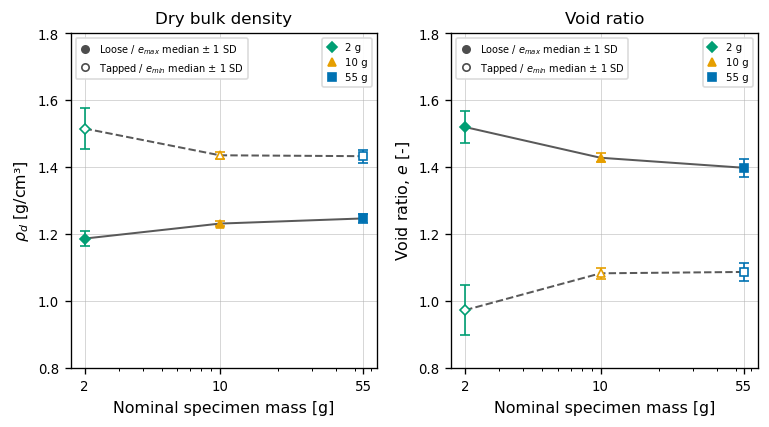

In [40]:
LT_PLOT_OPTS = {
    "show_replicates": True,
    "show_median": True,
    "show_sd": False,
    "show_ref_lines": True,
    "ylim_rho": (0.8, 1.80),
    "ylim_e": (0.8, 1.80),
    "ylim_tap_volnorm": (0.65, 1.05),
    "figsize_compare": (WORD_TEXT_WIDTH_IN, 3.65),
    "figsize_tap": (WORD_TEXT_WIDTH_IN, 4.0),
    "replicate_ls": {0: "-", 1: (0, (6, 2)), 2: (0, (1, 1.5))},
}
x = grouped["nominal_g"].to_numpy()


mass_handles = [Line2D([0],[0], marker=mass_marker(m), color=mass_color(m),
                        lw=0, markerfacecolor=mass_color(m), markersize=4.4,
                        label=f"{m:g} g") for m in sorted(set(x))]

# Figure 3.13 - medians with ±1 SD only.
fig3_lt_sd, (ax1s, ax2s) = plt.subplots(1, 2, figsize=LT_PLOT_OPTS["figsize_compare"])
for xi, yl, yl_err, yt, yt_err, ye_mx, ye_mx_sd, ye_mn, ye_mn_sd in zip(
        x, grouped["med_loose"], grouped["sd_loose"], grouped["med_tap"], grouped["sd_tap"],
        grouped["med_emax"], grouped["sd_emax"], grouped["med_emin"], grouped["sd_emin"]):
    col = mass_color(xi); mk = mass_marker(xi)
    ax1s.errorbar(xi, yl, yerr=yl_err, fmt=mk, ms=4.4, color=col, markerfacecolor=col, markeredgecolor=col, capsize=3, lw=1.0)
    ax1s.errorbar(xi, yt, yerr=yt_err, fmt=mk, ms=4.4, color=col, markerfacecolor="white", markeredgecolor=col, capsize=3, lw=1.0)
    ax2s.errorbar(xi, ye_mx, yerr=ye_mx_sd, fmt=mk, ms=4.4, color=col, markerfacecolor=col, markeredgecolor=col, capsize=3, lw=1.0)
    ax2s.errorbar(xi, ye_mn, yerr=ye_mn_sd, fmt=mk, ms=4.4, color=col, markerfacecolor="white", markeredgecolor=col, capsize=3, lw=1.0)
ax1s.plot(x, grouped["med_loose"], color="0.35", ls="-", lw=1.2)
ax1s.plot(x, grouped["med_tap"], color="0.35", ls="--", lw=1.2)
ax2s.plot(x, grouped["med_emax"], color="0.35", ls="-", lw=1.2)
ax2s.plot(x, grouped["med_emin"], color="0.35", ls="--", lw=1.2)
for axi, ylab, ytitle in [(ax1s, r"$\rho_d$ [g/cm³]", "Dry bulk density"), (ax2s, r"Void ratio, $e$ [-]", "Void ratio")]:
    axi.set_xscale("log")
    axi.set_xticks(sorted(x))
    axi.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    axi.set_xlabel("Nominal specimen mass [g]")
    axi.set_ylabel(ylab)
    axi.set_title(ytitle)
ax1s.set_ylim(LT_PLOT_OPTS["ylim_rho"]); ax2s.set_ylim(LT_PLOT_OPTS["ylim_e"])
state_handles_sd = [
    Line2D([0],[0], marker="o", lw=0, color="0.3", markerfacecolor="0.3",
           markersize=4.4, label="Loose / $e_{max}$ median ± 1 SD"),
    Line2D([0],[0], marker="o", lw=0, color="0.3", markerfacecolor="white",
           markersize=4.4, label="Tapped / $e_{min}$ median ± 1 SD"),
]
for axi in (ax1s, ax2s):
    leg1 = axi.legend(handles=state_handles_sd, frameon=True, facecolor="white", framealpha=0.94, edgecolor="0.85", fontsize=5.9, loc="upper left", handlelength=1.2)
    axi.add_artist(leg1)
    axi.legend(handles=mass_handles, frameon=True, facecolor="white", framealpha=0.94, edgecolor="0.85", fontsize=6.1, loc="upper right", ncol=1, handlelength=1.1)
plt.tight_layout()
savefig(fig3_lt_sd, "fig_3_13_density_void_ratio_sd")
plt.show()


Saved: figures/fig_3_14_tapping_normalized.pdf; Word SVG: figures_word/svg/fig_3_14_tapping_normalized.svg; Word PNG: figures_word/png_450dpi/fig_3_14_tapping_normalized.png


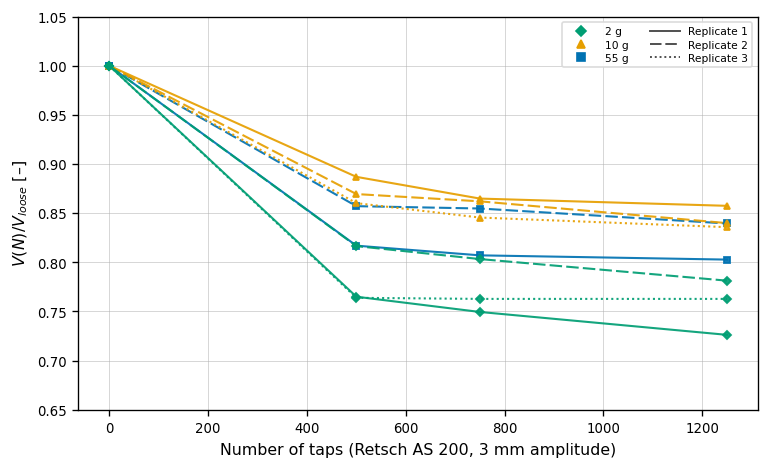

In [41]:
# -- Figure 3.14 - Tapping curve: V(N)/V_loose vs number of taps (B/W readable)
# B/W design: colour+marker per mass, linestyle per replicate (solid/dashed/dotted).
# This keeps each combination readable in both colour and black-and-white.
fig4_lt, ax = plt.subplots(figsize=LT_PLOT_OPTS["figsize_tap"])
taps = np.array([0, 500, 750, 1250])

CYL_LABEL = {100: "100 mL (diam. 25 mm)", 25: "25 mL (diam. 19 mm)", 10: "10 mL (diam. 15 mm)"}

rep_counter = {}   # assign per-mass replicate index
for _, row in df_lt.iterrows():
    V_loose_mean = float(row["V_loose_mean"]) if np.isfinite(row["V_loose_mean"]) else np.nan
    V_tap = [V_loose_mean, row["V_tap_500_mean"], row["V_tap_750_mean"], row["V_tap_1250_mean"]]
    V_tap = np.array([float(v) if np.isfinite(v) else np.nan for v in V_tap])
    if not np.isfinite(V_loose_mean) or V_loose_mean <= 0:
        continue
    ratio = V_tap / V_loose_mean
    m    = float(row["nominal_g"])
    col  = mass_color(m); mk = mass_marker(m)
    # Index replicates within each mass -> 0,1,2 for linestyle lookup
    rep_idx = rep_counter.get(m, 0)
    rep_counter[m] = rep_idx + 1
    ls  = LT_PLOT_OPTS["replicate_ls"].get(rep_idx, "-")
    ax.plot(taps, ratio, marker=mk, color=col, ls=ls,
            markerfacecolor=col, markeredgecolor=col, markeredgewidth=1.1,
            linewidth=1.25, alpha=0.92,
            label=f"{row['replicate']} ({m:g} g, {int(row['V_cyl_mL'])} mL)")

ax.set_xlabel("Number of taps (Retsch AS 200, 3 mm amplitude)")
ax.set_ylabel(r"$V(N)/V_{loose}$ [–]")
if LT_PLOT_OPTS["ylim_tap_volnorm"] is not None:
    ax.set_ylim(LT_PLOT_OPTS["ylim_tap_volnorm"])

# Two-part legend: mass (colour/marker) + replicate (linestyle)
mass_handles = [Line2D([0],[0], marker=mass_marker(mm), color=mass_color(mm),
                        lw=0, markerfacecolor=mass_color(mm), markersize=4.5,
                        label=f"{mm:g} g")
                for mm in sorted(df_lt["nominal_g"].unique())]
rep_handles = [Line2D([0],[0], color="0.3",
                       ls=LT_PLOT_OPTS["replicate_ls"].get(i, "-"),
                       lw=1.15, label=f"Replicate {i+1}") for i in range(3)]
ax.legend(handles=mass_handles + rep_handles,
          frameon=True, facecolor="white", framealpha=0.92, edgecolor="0.85",
          fontsize=6.4, ncol=2, loc="upper right", handlelength=2.8, labelspacing=0.32)
plt.tight_layout()
savefig(fig4_lt, "fig_3_14_tapping_normalized")
plt.show()


### 5.1 Export Thesis Tables

The final GitHub notebook also writes the thesis CSV tables to `tables/`, so the repository can be regenerated from the raw CSV inputs.


In [42]:
# ── Export thesis tables ------------------------------------------------------
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Table 3.1 - water content summary.
table_3_1 = pd.DataFrame([
    {
        "Specimen mass [g]": L,
        "n": len(wc_by_mass[L]),
        "Median w [%]": round(wc_median[L], 3),
        "SD [%]": round(wc_sd[L], 3) if np.isfinite(wc_sd[L]) else np.nan,
        "Δw vs 100 g [pp]": round(wc_median[L] - wc_ref, 3),
    }
    for L in sorted(wc_levels, reverse=True)
])
table_3_1.to_csv(TABLE_DIR / "table_3_1_water_content.csv", index=False)

# Table 3.2 - bulk pycnometer particle density.
table_3_2 = bulk.sort_values("mass_g", ascending=False).copy()
table_3_2 = table_3_2.assign(
    **{
        "Specimen mass [g]": table_3_2["mass_g"],
        "n": 1,
        "Median ρs [g/cm³]": table_3_2["rho_s"].round(4),
        "SD ρs [g/cm³]": np.nan,
        "Median Gs [−]": table_3_2["Gs"].round(4),
        "Δρs vs 20 g [g/cm³]": (table_3_2["rho_s"] - ref_rho_pyk).round(4),
    }
)[["Specimen mass [g]", "n", "Median ρs [g/cm³]", "SD ρs [g/cm³]", "Median Gs [−]", "Δρs vs 20 g [g/cm³]"]]
table_3_2.to_csv(TABLE_DIR / "table_3_2_particle_density_bulk.csv", index=False)

# Table 3.3 - particle-density fraction measurements.
table_3_3 = (df_pyk[df_pyk["fraction"] != "Bulk"]
    .rename(columns={
        "fraction": "Fraction",
        "mass_g": "Specimen mass [g]",
        "rho_s": "ρs [g/cm³]",
        "Gs": "Gs [−]",
    })[["Fraction", "Specimen mass [g]", "ρs [g/cm³]", "Gs [−]"]]
    .round({"Specimen mass [g]": 3, "ρs [g/cm³]": 4, "Gs [−]": 4}))
table_3_3.to_csv(TABLE_DIR / "table_3_3_particle_density_fractions.csv", index=False)

# Tables 3.4 and 3.5 - dry and wet sieve summaries.
def _sieve_summary(raw_filename, ref_keys):
    raw = pd.read_csv(DATA_DIR / raw_filename)
    initial = raw.groupby("test_id", sort=False)["initial_mass_g"].first()
    keys = list(initial.index)
    x_ref = SIEVES_MM[SIEVES_MM > 0]
    Y_ref = np.vstack([sieve_curve(k)[1] for k in ref_keys])
    y_ref = np.nanmedian(Y_ref, axis=0)
    rows = []
    for k in keys:
        x, y, recovered = sieve_curve(k)
        diff = y - y_ref
        rows.append({
            "Test": k,
            "Initial mass [g]": round(float(initial.loc[k]), 3),
            "Recovered mass [g]": round(float(recovered), 3),
            "Loss [%]": round((float(initial.loc[k]) - float(recovered)) / float(initial.loc[k]) * 100, 2),
            "Passing 0.075 mm [%]": round(float(p075(k)), 2),
            "D50 [mm]": round(float(D_at_pct(x, y, 50)), 4) if np.isfinite(D_at_pct(x, y, 50)) else np.nan,
            "Max dev vs ref [pp]": round(float(np.nanmax(np.abs(diff))), 2),
            "RMS dev vs ref [pp]": round(float(np.sqrt(np.nanmean(diff**2))), 2),
        })
    return pd.DataFrame(rows)

table_3_4 = _sieve_summary("dry_sieve_raw.csv", ["50A", "50B"])
table_3_5 = _sieve_summary("wet_sieve_raw.csv", ["100W1", "100W2"])
table_3_4.to_csv(TABLE_DIR / "table_3_4_dry_sieve_summary.csv", index=False)
table_3_5.to_csv(TABLE_DIR / "table_3_5_wet_sieve_summary.csv", index=False)

# Table 3.6 - hydrometer quality metrics.
_hydro_ref = ["50A", "50B"]
_hydro_grid = np.logspace(np.log10(0.003), np.log10(0.05), 60)
_hydro_ref_y = np.nanmean(np.vstack([interp_to_grid(*hydro_curve(k), _hydro_grid) for k in _hydro_ref]), axis=0)
table_3_6_rows = []
for k in HYDRO_KEYS:
    df_h = HYDRO_WITH[k]
    y_k = interp_to_grid(*hydro_curve(k), _hydro_grid)
    table_3_6_rows.append({
        "Test": k,
        "Dry mass [g]": round(float(df_h["Md_g"].iloc[0]), 3),
        "Max corrected signal": round(float(df_h["signal"].max()), 2),
        "Low-signal fraction": round(float(df_h["low_signal"].mean()), 2),
        "RMS dev vs 50 g [pp]": round(float(np.sqrt(np.nanmean((y_k - _hydro_ref_y)**2))), 2),
    })
table_3_6 = pd.DataFrame(table_3_6_rows)
table_3_6.to_csv(TABLE_DIR / "table_3_6_hydro_quality.csv", index=False)

# Table 3.7 - stitched gradation metrics. Re-export after the corrected D interpolation.
df_grad.to_csv(TABLE_DIR / "table_3_7_gradation_stitched.csv", index=False)

# Tables 3.8 and 3.9 - loose/tapped density summaries.
def _fmt_pm(m, s, prec=3):
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.{prec}f}"
    return f"{m:.{prec}f} ± {s:.{prec}f}"

def _loose_tapped_summary(df):
    g = (df.groupby("nominal_g", as_index=False)
           .agg(n=("replicate", "count"),
                med_loose=("rho_loose", "median"), sd_loose=("rho_loose", "std"),
                med_tap=("rho_tap", "median"), sd_tap=("rho_tap", "std"),
                med_gmin=("gamma_d_min", "median"), sd_gmin=("gamma_d_min", "std"),
                med_gmax=("gamma_d_max", "median"), sd_gmax=("gamma_d_max", "std"),
                med_emax=("e_max", "median"), sd_emax=("e_max", "std"),
                med_emin=("e_min", "median"), sd_emin=("e_min", "std")))
    return pd.DataFrame({
        "Mass group [g]": [f"{int(m) if float(m).is_integer() else m:g}" for m in g["nominal_g"]],
        "n": g["n"].astype(int),
        "ρ_loose [g/cm³]": [_fmt_pm(m, s, 3) for m, s in zip(g["med_loose"], g["sd_loose"])],
        "ρ_tapped [g/cm³]": [_fmt_pm(m, s, 3) for m, s in zip(g["med_tap"], g["sd_tap"])],
        "γ_d,min [kN/m³]": [_fmt_pm(m, s, 2) for m, s in zip(g["med_gmin"], g["sd_gmin"])],
        "γ_d,max [kN/m³]": [_fmt_pm(m, s, 2) for m, s in zip(g["med_gmax"], g["sd_gmax"])],
        "e_max (loose) [−]": [_fmt_pm(m, s, 3) for m, s in zip(g["med_emax"], g["sd_emax"])],
        "e_min (tapped) [−]": [_fmt_pm(m, s, 3) for m, s in zip(g["med_emin"], g["sd_emin"])],
    })

main_lt = df_lt[~((df_lt["nominal_g"] == 10) & (df_lt["V_cyl_mL"] == 10))].copy()
table_3_8 = _loose_tapped_summary(main_lt)
table_3_8.to_csv(TABLE_DIR / "table_3_8_loose_tapped.csv", index=False)

ten = df_lt[df_lt["nominal_g"] == 10].copy()
ten_group = (ten.groupby(["nominal_g", "V_cyl_mL", "D_cyl_mm"], as_index=False)
    .agg(n=("replicate", "count"),
         med_loose=("rho_loose", "median"), sd_loose=("rho_loose", "std"),
         med_tap=("rho_tap", "median"), sd_tap=("rho_tap", "std"),
         med_emax=("e_max", "median"), sd_emax=("e_max", "std"),
         med_emin=("e_min", "median"), sd_emin=("e_min", "std")))
table_3_9 = pd.DataFrame({
    "Nominal mass [g]": [f"{m:g}" for m in ten_group["nominal_g"]],
    "Cylinder volume [mL]": [f"{v:g}" for v in ten_group["V_cyl_mL"]],
    "Cylinder diameter [mm]": [f"{d:g}" for d in ten_group["D_cyl_mm"]],
    "n": ten_group["n"].astype(int),
    "ρ_loose [g/cm³]": [_fmt_pm(m, s, 3) for m, s in zip(ten_group["med_loose"], ten_group["sd_loose"])],
    "ρ_tapped [g/cm³]": [_fmt_pm(m, s, 3) for m, s in zip(ten_group["med_tap"], ten_group["sd_tap"])],
    "e_max [−]": [_fmt_pm(m, s, 3) for m, s in zip(ten_group["med_emax"], ten_group["sd_emax"])],
    "e_min [−]": [_fmt_pm(m, s, 3) for m, s in zip(ten_group["med_emin"], ten_group["sd_emin"])],
})
table_3_9.to_csv(TABLE_DIR / "table_3_9_loose_tapped_10g_cylinder.csv", index=False)

# Tables 4.1 and 4.2 - mineral-density estimate.
table_4_1 = pd.read_csv(DATA_DIR / "mineral_composition.csv")
table_4_1.to_csv(TABLE_DIR / "table_4_1_mineral_components.csv", index=False)

def _mixture_density(col):
    w = table_4_1["Wt [%]"].astype(float) / 100.0
    rho = table_4_1[col].astype(float)
    return float(1.0 / np.sum(w / rho))

rho_lower = _mixture_density("ρ lower [g/cm³]")
rho_mean = _mixture_density("ρ mean [g/cm³]")
rho_upper = _mixture_density("ρ upper [g/cm³]")
table_4_2 = pd.DataFrame({
    "Estimate": ["Lower estimate", "Mean estimate", "Upper estimate", "Representative estimate"],
    "Particle density [g/cm³]": [round(rho_lower, 2), round(rho_mean, 2), round(rho_upper, 2), f"{rho_mean:.2f} ± 0.20"],
})
table_4_2.to_csv(TABLE_DIR / "table_4_2_rho_estimate.csv", index=False)

exported_tables = sorted(p.name for p in TABLE_DIR.glob("table_*.csv"))
print("Exported thesis tables:")
for name in exported_tables:
    print(f"- {name}")


Exported thesis tables:
- table_3_1_water_content.csv
- table_3_2_particle_density_bulk.csv
- table_3_3_particle_density_fractions.csv
- table_3_4_dry_sieve_summary.csv
- table_3_5_wet_sieve_summary.csv
- table_3_6_hydro_quality.csv
- table_3_7_gradation_stitched.csv
- table_3_8_loose_tapped.csv
- table_3_9_loose_tapped_10g_cylinder.csv
- table_4_1_mineral_components.csv
- table_4_2_rho_estimate.csv


/var/folders/yk/p9xt55dn7db11tf12zx3t_5c0000gn/T/ipykernel_88704/825031041.py:74: RuntimeWarning: Mean of empty slice
  _hydro_ref_y = np.nanmean(np.vstack([interp_to_grid(*hydro_curve(k), _hydro_grid) for k in _hydro_ref]), axis=0)
